In [64]:
import pandas as pd
import numpy as np

# ============================
# STEP 3A — PART 1: Load Data & Promotions Flag (explicit MDY/DMY rules)
# ============================

print("🚀 STEP 3A — PART 1: Load Data & Promotions Flag (explicit MDY/DMY rules)")
print("="*78)

# ---- 1) Load CSVs ----
sales  = pd.read_csv("Assignment4.1a.csv")
promos = pd.read_csv("Promotiondates.csv")

print(f"✓ Sales: {sales.shape[0]} rows | Columns: {list(sales.columns)}")
print(f"✓ Promotions: {promos.shape[0]} rows | Columns: {list(promos.columns)}")

# ---- 2) Sales tarihleri ----
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
sales = sales.dropna(subset=["Date"]).reset_index(drop=True)

# ---- 3) Period kolonunu garanti et ----
if "Period" not in promos.columns:
    promos = promos.copy()
    promos["Period"] = [f"Promo{i}" for i in range(1, len(promos) + 1)]

# ---- 4) P1–P4 = MDY, P5–P6 = DMY (explicit) ----
period_str = promos["Period"].astype(str)
is_p56 = period_str.str.contains(r"Promo5|Promo6", case=False) | period_str.str.fullmatch(r"[56]")

def parse_with(series, dayfirst=False):
    return pd.to_datetime(series, errors="coerce", dayfirst=dayfirst)

# P1–P4: MDY
promos.loc[~is_p56, "StartDate"] = parse_with(promos.loc[~is_p56, "StartDate"], dayfirst=False)
promos.loc[~is_p56, "EndDate"]   = parse_with(promos.loc[~is_p56, "EndDate"],   dayfirst=False)

# P5–P6: DMY
promos.loc[is_p56, "StartDate"] = parse_with(promos.loc[is_p56, "StartDate"], dayfirst=True)
promos.loc[is_p56, "EndDate"]   = parse_with(promos.loc[is_p56, "EndDate"],   dayfirst=True)

# ---- 5) Kalite kontrolleri ----
# a) Parse edilemeyen satırlar
bad = promos["StartDate"].isna() | promos["EndDate"].isna()
if bad.any():
    print("⚠️ Unparseable promo dates, dropping rows:")
    print(promos.loc[bad, ["Period","StartDate","EndDate"]].to_string(index=False))
    promos = promos.loc[~bad].copy()

# b) End < Start ise swap
swap_mask = promos["EndDate"] < promos["StartDate"]
if swap_mask.any():
    print(f"ℹ️ Swapping Start/End on {swap_mask.sum()} rows (EndDate < StartDate).")
    s = promos.loc[swap_mask, "StartDate"].copy()
    promos.loc[swap_mask, "StartDate"] = promos.loc[swap_mask, "EndDate"]
    promos.loc[swap_mask, "EndDate"]   = s

# c) .dt hatasına kesin çözüm: son kez datetime64'e cast
for col in ["StartDate", "EndDate"]:
    promos[col] = pd.to_datetime(promos[col], errors="coerce")

# d) Süre kontrolü (~7 gün beklenir)
promos["DurationDays"] = (promos["EndDate"] - promos["StartDate"]).dt.days + 1
long_or_bad = (promos["DurationDays"] <= 0) | (promos["DurationDays"] > 14)
if long_or_bad.any():
    print("\n⚠️ Anomalous promo windows (expected ≈ 7 days):")
    print(promos.loc[long_or_bad, ["Period","StartDate","EndDate","DurationDays"]]
              .sort_values("Period").to_string(index=False))

# Görsel kontrol için MDY stringleri
promos["_Start_MDY"] = promos["StartDate"].dt.strftime("%m/%d/%Y")
promos["_End_MDY"]   = promos["EndDate"].dt.strftime("%m/%d/%Y")
print("\n✅ Normalized promo windows (MDY view):")
print(promos[["Period","_Start_MDY","_End_MDY","DurationDays"]]
      .sort_values("Period").to_string(index=False))

# ---- 6) Time-based tagging (merge_asof) ----
sales_sorted  = sales.sort_values("Date").reset_index(drop=False).rename(columns={"index":"_orig_idx"})
promos_sorted = promos.sort_values("StartDate").reset_index(drop=True)

asof = pd.merge_asof(
    sales_sorted,
    promos_sorted[["Period","StartDate","EndDate"]],
    left_on="Date", right_on="StartDate",
    direction="backward",
    allow_exact_matches=True
)

in_range = asof["Date"].le(asof["EndDate"])
asof["PromoPeriod"] = np.where(in_range, asof["Period"], "NoPromo")
asof["IsPromotion"] = in_range.fillna(False)

# Orijinal sıra + kolonlar
sales_tagged = (asof
    .sort_values("_orig_idx")
    .drop(columns=["_orig_idx","StartDate","EndDate","Period"])
    .reset_index(drop=True))

print("\n✓ PromoPeriod + IsPromotion columns created.")

# ---- 7) Özetler ----
print("\n📌 Rows per PromoPeriod:")
print(sales_tagged["PromoPeriod"].value_counts(dropna=False).sort_index().to_string())

totals = sales_tagged.groupby("PromoPeriod", as_index=False)["SalesQuantity"].sum()
print("\n🧮 Total SalesQuantity by PromoPeriod:")
print(totals.sort_values("PromoPeriod").to_string(index=False))

print("\n🔎 Sample tagged rows:")
print(sales_tagged.loc[:, ["Date","StoreCode","ProductCode","SalesQuantity","PromoPeriod","IsPromotion"]]
      .head(10).to_string(index=False))

print("\n🗓️ Sales date range:", sales_tagged["Date"].min().date(), "→", sales_tagged["Date"].max().date())

# (Opsiyonel) çıktılar:
# promos.drop(columns=["_Start_MDY","_End_MDY"]).to_csv("promos_cleaned.csv", index=False)
# sales_tagged.to_csv("sales_tagged.csv", index=False)


🚀 STEP 3A — PART 1: Load Data & Promotions Flag (explicit MDY/DMY rules)
✓ Sales: 1873618 rows | Columns: ['Date', 'StoreCode', 'ProductCode', 'SalesQuantity']
✓ Promotions: 6 rows | Columns: ['Period', 'StartDate', 'EndDate']

✅ Normalized promo windows (MDY view):
 Period _Start_MDY   _End_MDY  DurationDays
 Promo1 02/10/2015 02/17/2015             8
 Promo2 03/15/2015 03/22/2015             8
 Promo3 05/24/2015 06/01/2015             9
 Promo4 06/21/2015 06/28/2015             8
 Promo5 09/01/2015 09/06/2015             6
Promo6  11/20/2015 11/27/2015             8

✓ PromoPeriod + IsPromotion columns created.

📌 Rows per PromoPeriod:
PromoPeriod
NoPromo    1562695
Promo1       80876
Promo2       85678
Promo3       76546
Promo4       67823

🧮 Total SalesQuantity by PromoPeriod:
PromoPeriod  SalesQuantity
    NoPromo        3399463
     Promo1         196852
     Promo2         222762
     Promo3         206525
     Promo4         183728

🔎 Sample tagged rows:
      Date  StoreCode  

In [65]:
# ---- Time-based tagging (PromoPeriod & IsPromotion ekleme) ----
sales_sorted  = sales.sort_values("Date").reset_index(drop=False).rename(columns={"index":"_orig_idx"})
promos_sorted = promos.sort_values("StartDate").reset_index(drop=True)

asof = pd.merge_asof(
    sales_sorted,
    promos_sorted[["Period","StartDate","EndDate"]],
    left_on="Date", right_on="StartDate",
    direction="backward",
    allow_exact_matches=True
)

# Etiketleme
in_range = asof["Date"].le(asof["EndDate"])
asof["PromoPeriod"] = np.where(in_range, asof["Period"], "NoPromo")
asof["IsPromotion"] = in_range.fillna(False)

# Orijinal sırayı geri getir ve sales’e ata
sales = (asof
         .sort_values("_orig_idx")
         .drop(columns=["_orig_idx","StartDate","EndDate","Period"])
         .reset_index(drop=True))

In [66]:
print("\n📌 Rows per PromoPeriod:")
print(sales["PromoPeriod"].value_counts(dropna=False).sort_index().to_string())

totals = sales.groupby("PromoPeriod", as_index=False)["SalesQuantity"].sum()
print("\n🧮 Total SalesQuantity by PromoPeriod:")
print(totals.sort_values("PromoPeriod").to_string(index=False))

print("\n🔎 Sample tagged rows:")
print(sales.loc[:, ["Date","StoreCode","ProductCode","SalesQuantity","PromoPeriod","IsPromotion"]]
          .head(20).to_string(index=False))

print("\n🗓️ Sales date range:", sales["Date"].min().date(), "→", sales["Date"].max().date())




📌 Rows per PromoPeriod:
PromoPeriod
NoPromo    1562695
Promo1       80876
Promo2       85678
Promo3       76546
Promo4       67823

🧮 Total SalesQuantity by PromoPeriod:
PromoPeriod  SalesQuantity
    NoPromo        3399463
     Promo1         196852
     Promo2         222762
     Promo3         206525
     Promo4         183728

🔎 Sample tagged rows:
      Date  StoreCode  ProductCode  SalesQuantity PromoPeriod  IsPromotion
2015-01-01          8            9             -1     NoPromo        False
2015-01-01        131            9              1     NoPromo        False
2015-01-01        144            9              2     NoPromo        False
2015-01-01        203            9              2     NoPromo        False
2015-01-01        256            9              0     NoPromo        False
2015-01-01        273            9              1     NoPromo        False
2015-01-02         12            9              0     NoPromo        False
2015-01-02         52            9          

In [70]:
# ============================
# STEP 3B — PART 2: Weekly panel + non-promo performance features
# ============================

import pandas as pd
import numpy as np

print("🧱 STEP 3B — Weekly panel + performance features (no clustering yet)")
print("="*70)

# =====================================================
# 📌 METRIC DEFINITIONS (used for clustering later)
# -----------------------------------------------------
# Product-level (non-promotion):
#   total_nonpromo_sales  = total units sold in non-promo periods
#   n_store_weeks_nonpromo = number of (store, week) combinations 
#                             where product had at least 1 non-promo sale
#   avg_weekly_sales_per_store = total_nonpromo_sales / n_store_weeks_nonpromo
#
# Store-level (non-promotion):
#   total_nonpromo_sales  = total units sold in non-promo periods
#   n_product_weeks_nonpromo = number of (product, week) combinations 
#                               with at least 1 non-promo sale
#   avg_weekly_sales_per_product = total_nonpromo_sales / n_product_weeks_nonpromo
# =====================================================

# --- Required columns check ---
required_cols = {"Date","StoreCode","ProductCode","SalesQuantity","IsPromotion"}
missing = required_cols - set(sales.columns)
if missing:
    raise ValueError(f"DataFrame 'sales' is missing columns: {missing}")

# --- Parameters ---
CLIP_NEGATIVES = True      # replace returns (negative sales) with 0
WEEK_START = "W-MON"       # weeks start on Monday

# 1) Prepare base dataframe
sales2 = sales.copy()
sales2["Date"] = pd.to_datetime(sales2["Date"], errors="coerce")
if CLIP_NEGATIVES:
    sales2["NetSales"] = np.where(sales2["SalesQuantity"] < 0, 0, sales2["SalesQuantity"])
else:
    sales2["NetSales"] = sales2["SalesQuantity"]

# Week start (weekly aggregation key)
sales2["WeekStart"] = sales2["Date"].dt.to_period(WEEK_START).dt.start_time

# Separate promo vs non-promo contributions
sales2["NonPromoSales"] = np.where(sales2["IsPromotion"], 0, sales2["NetSales"])
sales2["PromoSales"]    = np.where(sales2["IsPromotion"], sales2["NetSales"], 0)
sales2["NonPromoFlag"]  = (~sales2["IsPromotion"]).astype(int)
sales2["PromoFlag"]     = (sales2["IsPromotion"]).astype(int)

# 2) Aggregate to Store–Product–Week level
grp = ["StoreCode","ProductCode","WeekStart"]
wk = (sales2
      .groupby(grp, as_index=False)
      .agg(
          nonpromo_sales = ("NonPromoSales","sum"),
          promo_sales    = ("PromoSales","sum"),
          nonpromo_days  = ("NonPromoFlag","sum"),
          promo_days     = ("PromoFlag","sum")
      ))

wk["total_sales"] = wk["nonpromo_sales"] + wk["promo_sales"]
wk["has_nonpromo"] = wk["nonpromo_days"] > 0
wk["has_promo"]    = wk["promo_days"] > 0

print(f"✓ Weekly panel ready: {wk.shape[0]:,} rows (Store–Product–Week)")

# 3) Product-level non-promo performance
product_perf = (wk
    .groupby("ProductCode", as_index=False)
    .agg(
        total_nonpromo_sales = ("nonpromo_sales","sum"),
        n_store_weeks_nonpromo = ("has_nonpromo","sum")
    ))

product_perf["avg_weekly_sales_per_store"] = (
    product_perf["total_nonpromo_sales"] /
    product_perf["n_store_weeks_nonpromo"].replace({0: np.nan})
)

# 4) Store-level non-promo performance
store_perf = (wk
    .groupby("StoreCode", as_index=False)
    .agg(
        total_nonpromo_sales = ("nonpromo_sales","sum"),
        n_product_weeks_nonpromo = ("has_nonpromo","sum")
    ))

store_perf["avg_weekly_sales_per_product"] = (
    store_perf["total_nonpromo_sales"] /
    store_perf["n_product_weeks_nonpromo"].replace({0: np.nan})
)

# 5) Quick quality checks
def qc(df, value_col, key_col):
    print(f"\n🔎 QC → {key_col}: {df.shape[0]} rows,"
          f" {value_col} null ratio: {df[value_col].isna().mean():.2%},"
          f" min/max: {df[value_col].min(skipna=True)} / {df[value_col].max(skipna=True)}")

qc(product_perf, "avg_weekly_sales_per_store", "ProductCode")
qc(store_perf,   "avg_weekly_sales_per_product", "StoreCode")

print("\nExample (Products):")
print(product_perf.head(10).to_string(index=False))
print("\nExample (Stores):")
print(store_perf.head(10).to_string(index=False))

# 6) Final features for clustering
PRODUCT_FEATURE_COL = "avg_weekly_sales_per_store"
STORE_FEATURE_COL   = "avg_weekly_sales_per_product"

print("\n✅ STEP 3B complete: 'wk', 'product_perf', 'store_perf' ready (these features will be used for clustering).")

🧱 STEP 3B — Weekly panel + performance features (no clustering yet)
✓ Weekly panel ready: 1,053,837 rows (Store–Product–Week)

🔎 QC → ProductCode: 317 rows, avg_weekly_sales_per_store null ratio: 0.32%, min/max: 0.0 / 33.03402667872485

🔎 QC → StoreCode: 340 rows, avg_weekly_sales_per_product null ratio: 0.00%, min/max: 0.0 / 8.417659018297996

Example (Products):
 ProductCode  total_nonpromo_sales  n_store_weeks_nonpromo  avg_weekly_sales_per_store
           1                  9447                    2662                    3.548835
           2                  7115                    2358                    3.017388
           3                  5181                    2183                    2.373339
           4                  6335                    2184                    2.900641
           5                  7633                    2721                    2.805219
           6                  1220                    2063                    0.591372
           7            

In [72]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==== CONFIG ====
FEATURE = "avg_weekly_sales_per_store"  # ürün hızı metriği (non-promo)

# ---- 0) Sayısal özet: toplam ürün vs kullanılabilen ürün
total_products = product_perf.shape[0]

# hangi ürünlerin feature'ı var (NaN değil)?
mask_valid = product_perf[FEATURE].notna()
X_df = product_perf.loc[mask_valid, [FEATURE]].copy()   # DF (index korunur)
X_vals = X_df.values                                    # NP -> model için

print(f"Toplam ürün: {total_products}")
print(f"Kümelemeye giren ürün: {X_df.shape[0]}")
print(f"Dışarıda kalan ürün: {total_products - X_df.shape[0]}")

# ---- 0.a) Dışarıda kalanları ve nedeni (reason) raporla
excluded_idx = product_perf.index.difference(X_df.index)
excluded_products = product_perf.loc[excluded_idx, ["ProductCode",
                                                    FEATURE,
                                                    "total_nonpromo_sales",
                                                    "n_store_weeks_nonpromo"]].copy()

# neden: çoğu 0/0 -> NaN (hiç non-promo store-week yok)
excluded_products["reason"] = np.where(
    excluded_products["n_store_weeks_nonpromo"].fillna(0) == 0,
    "no non-promo store-week (0/0 → NaN)",
    "missing feature value"
)

print("\nClustering dışında kalan ürünler (ilk 20):")
print(excluded_products.head(20).to_string(index=False))

# ---- 1) Standartlaştırma
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vals)

# ---- 2) K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_scaled)

# ---- 3) Etiketleri geri yaz
df_prod = product_perf.copy()
df_prod["cluster_id"] = np.nan
df_prod.loc[X_df.index, "cluster_id"] = labels

# merkezler: scaled & orijinal ölçek
centers_scaled = kmeans.cluster_centers_.ravel()
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_).ravel()

# orijinal ölçeğe göre küçükten büyüğe sırala ve isimlendir
order = np.argsort(centers_unscaled)
label_map = {order[0]: "Slow", order[1]: "Medium", order[2]: "Fast"}
df_prod["cluster_label"] = df_prod["cluster_id"].map(label_map)

print("\nCluster centers (scaled):", np.round(centers_scaled, 3))
print("Cluster centers (original units):", np.round(centers_unscaled[order], 3))

# pratik (yaklaşık) eşikler: merkezlerin orta noktaları
t1 = (centers_unscaled[order][0] + centers_unscaled[order][1]) / 2
t2 = (centers_unscaled[order][1] + centers_unscaled[order][2]) / 2
print(f"Suggested cutoffs (original units): Slow <~ {t1:.3f}, "
      f"Medium ~[{t1:.3f}, {t2:.3f}), Fast >=~ {t2:.3f}")

# ---- 4) Küme özeti (orijinal ölçekte)
summary = (df_prod
           .groupby("cluster_label")[FEATURE]
           .agg(["count","mean","median","min","max"])
           .sort_values("mean"))
print("\nCluster summary (original units):")
print(summary)

# ---- 5) Sonuçları ana tabloya geri yaz (product_perf güncelle)
product_perf["cluster_id"] = df_prod["cluster_id"]
product_perf["cluster_label"] = df_prod["cluster_label"]

# Ayrıca dışarıdakileri ayrı değişkende tutmak istersen:
products_excluded = excluded_products.copy()

# ---- 6) Örnek satırlar
print("\nSample products with labels:")
print(product_perf.loc[product_perf["cluster_label"].notna(),
                       ["ProductCode", FEATURE, "cluster_label"]]
      .head(10).to_string(index=False))


Toplam ürün: 317
Kümelemeye giren ürün: 316
Dışarıda kalan ürün: 1

Clustering dışında kalan ürünler (ilk 20):
 ProductCode  avg_weekly_sales_per_store  total_nonpromo_sales  n_store_weeks_nonpromo                              reason
         261                         NaN                     0                       0 no non-promo store-week (0/0 → NaN)

Cluster centers (scaled): [-0.289  5.47   1.164]
Cluster centers (original units): [ 1.4    6.349 21.02 ]
Suggested cutoffs (original units): Slow <~ 3.875, Medium ~[3.875, 13.684), Fast >=~ 13.684

Cluster summary (original units):
               count       mean     median        min        max
cluster_label                                                   
Slow             271   1.400339   1.109747   0.000000   3.729355
Medium            39   6.348813   5.723338   3.892615  12.755548
Fast               6  21.019639  18.116057  15.921186  33.034027

Sample products with labels:
 ProductCode  avg_weekly_sales_per_store cluster_label

In [74]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==== CONFIG ====
FEATURE = "avg_weekly_sales_per_product"   # mağaza hızı metriği (non-promo)

# ---- 0) Özet: toplam / geçerli / dışarıda kalan
total_stores = store_perf.shape[0]
mask_valid = store_perf[FEATURE].notna()
X_df = store_perf.loc[mask_valid, [FEATURE]].copy()   # DF (index korunur)
X_vals = X_df.values                                  # NP -> model için

print(f"Toplam mağaza: {total_stores}")
print(f"Kümelemeye giren mağaza: {X_df.shape[0]}")
print(f"Dışarıda kalan: {total_stores - X_df.shape[0]}")

# ---- 0.a) Dışarıda kalanları ve nedeni raporla
excluded_idx = store_perf.index.difference(X_df.index)
excluded_stores = store_perf.loc[
    excluded_idx,
    ["StoreCode", FEATURE, "total_nonpromo_sales", "n_product_weeks_nonpromo"]
].copy()

excluded_stores["reason"] = np.where(
    excluded_stores["n_product_weeks_nonpromo"].fillna(0) == 0,
    "no non-promo product-week (0/0 → NaN)",
    "missing feature value"
)

print("\nClustering dışında kalan mağazalar (ilk 10):")
print(excluded_stores.head(10).to_string(index=False))

# ---- 1) Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vals)

# ---- 2) K-Means (k=3)
kmeans_store = KMeans(n_clusters=3, random_state=42, n_init=20)
labels = kmeans_store.fit_predict(X_scaled)

# ---- 3) Etiketleri geri yaz
df_store = store_perf.copy()
df_store["cluster_id"] = np.nan
df_store.loc[X_df.index, "cluster_id"] = labels

# Merkezleri ölçeklerde hesapla
centers_scaled = kmeans_store.cluster_centers_.ravel()
centers_orig   = scaler.inverse_transform(kmeans_store.cluster_centers_).ravel()

# Orijinal ölçekte küçükten büyüğe sırala ve isimlendir
order = np.argsort(centers_orig)
label_map = {order[0]: "Slow", order[1]: "Medium", order[2]: "Fast"}
df_store["cluster_label"] = df_store["cluster_id"].map(label_map)

print("\nCluster centers (scaled):", np.round(centers_scaled, 3))
print("Cluster centers (original units):", np.round(centers_orig[order], 3))

# Yaklaşık eşikler (merkezlerin orta noktaları)
t1 = (centers_orig[order][0] + centers_orig[order][1]) / 2
t2 = (centers_orig[order][1] + centers_orig[order][2]) / 2
print(f"Suggested cutoffs: Slow <~ {t1:.3f}, Medium ~[{t1:.3f}, {t2:.3f}), Fast >=~ {t2:.3f}")

# ---- 4) Küme özeti
summary = (df_store
           .groupby("cluster_label")[FEATURE]
           .agg(["count", "mean", "median", "min", "max"])
           .sort_values("mean"))
print("\nCluster summary (original units):")
print(summary)

# ---- 5) Sonuçları ana tabloya yaz
store_perf["cluster_id"] = df_store["cluster_id"]
store_perf["cluster_label"] = df_store["cluster_label"]
stores_excluded = excluded_stores.copy()

# ---- 6) Örnek satırlar
print("\nSample stores with labels:")
print(store_perf.loc[store_perf["cluster_label"].notna(),
                     ["StoreCode", FEATURE, "cluster_label"]]
      .head(10).to_string(index=False))



Toplam mağaza: 340
Kümelemeye giren mağaza: 340
Dışarıda kalan: 0

Clustering dışında kalan mağazalar (ilk 10):
Empty DataFrame
Columns: [StoreCode, avg_weekly_sales_per_product, total_nonpromo_sales, n_product_weeks_nonpromo, reason]
Index: []

Cluster centers (scaled): [-0.661  2.272  0.332]
Cluster centers (original units): [2.627 3.936 6.491]
Suggested cutoffs: Slow <~ 3.281, Medium ~[3.281, 5.213), Fast >=~ 5.213

Cluster summary (original units):
               count      mean    median       min       max
cluster_label                                               
Slow             182  2.626804  2.716919  0.000000  3.275069
Medium           123  3.936112  3.851812  3.290957  5.133425
Fast              35  6.490663  6.087038  5.239764  8.417659

Sample stores with labels:
 StoreCode  avg_weekly_sales_per_product cluster_label
         1                      3.461590        Medium
         2                      7.969725          Fast
         3                      3.009670     

In [26]:
# ============================================================
# PART 3 — Prediction Model (Weekly, Two‑Stage, Linear, BOTH CLUSTERS)
# ============================================================

import pandas as pd, numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

DATE_COL  = "Date"
SALES_COL = "SalesQuantity"
KEYS      = ["StoreCode","ProductCode"]

PATH_A   = "Assignment4.1a.csv"
PATH_B   = "Assignment4.1b.csv"
PATH_P   = "Promotiondates.csv"
PATH_SKU = "Assignment4.1c.csv"   # opsiyonel

# ---------- 0) Smart date parser ----------
def smart_parse_date_series(s):
    if np.issubdtype(s.dtype, np.number):
        return pd.to_datetime(s, errors="coerce", origin="1899-12-30", unit="D")
    st = s.astype(str).str.strip().replace({"": np.nan})
    st = st.str.replace(r"[.\-]", "/", regex=True)
    p0 = pd.to_datetime(st, errors="coerce", dayfirst=False)  # MDY
    p1 = pd.to_datetime(st, errors="coerce", dayfirst=True)   # DMY
    out = p1 if p1.notna().sum() > p0.notna().sum() else p0
    p_iso = pd.to_datetime(st, errors="coerce", utc=False)
    if p_iso.notna().sum() > out.notna().sum():
        out = p_iso
    return out

def load_sales(path):
    df_raw = pd.read_csv(path)
    print(f"\n[LOAD] {path}: raw rows = {df_raw.shape[0]}")
    df = df_raw.copy()
    df[DATE_COL] = smart_parse_date_series(df[DATE_COL])
    bad = df[DATE_COL].isna().sum()
    if bad: print(f"  - rows with unparseable Date: {bad}")
    df = df.dropna(subset=[DATE_COL]).reset_index(drop=True)
    print(f"  -> after smart date parse: {df.shape[0]} rows")
    return df

sales_a = load_sales(PATH_A)
sales_b = load_sales(PATH_B)

# ---------- 1) Promotions (P1-4 MDY, P5-6 DMY) ----------
def load_promos(path):
    promos = pd.read_csv(path).copy()
    if "Period" not in promos.columns:
        promos["Period"] = [f"Promo{i}" for i in range(1, len(promos)+1)]
    def norm_period(x):
        s = str(x).strip()
        if s.lower().startswith("promo"):
            n = "".join(ch for ch in s if ch.isdigit())
            return f"Promo{n}" if n else s
        return f"Promo{s}" if s.isdigit() else s
    promos["Period"] = promos["Period"].map(norm_period)

    start_col = [c for c in promos.columns if c.lower().startswith("start")][0]
    end_col   = [c for c in promos.columns if c.lower().startswith("end")][0]

    num = promos["Period"].str.extract(r"(\d+)").astype(int).squeeze()
    is_p56 = num.isin([5,6])

    def _parse(x, dayfirst):
        s = pd.Series(x).astype(str).str.strip().str.replace(r"[.\-]", "/", regex=True)
        d = pd.to_datetime(s, errors="coerce", dayfirst=dayfirst)
        m_num = s.str.fullmatch(r"\d+")
        if m_num.any():
            d.loc[m_num] = pd.to_datetime(s.loc[m_num].astype(float), errors="coerce",
                                          origin="1899-12-30", unit="D")
        return d

    promos.loc[~is_p56, "StartDate"] = _parse(promos.loc[~is_p56, start_col], dayfirst=False)
    promos.loc[~is_p56, "EndDate"]   = _parse(promos.loc[~is_p56, end_col],   dayfirst=False)
    promos.loc[ is_p56, "StartDate"] = _parse(promos.loc[ is_p56, start_col], dayfirst=True)
    promos.loc[ is_p56, "EndDate"]   = _parse(promos.loc[ is_p56, end_col],   dayfirst=True)

    swap = promos["EndDate"] < promos["StartDate"]
    if swap.any():
        t = promos.loc[swap, "StartDate"].copy()
        promos.loc[swap, "StartDate"] = promos.loc[swap, "EndDate"]
        promos.loc[swap, "EndDate"]   = t

    promos["StartDate"] = pd.to_datetime(promos["StartDate"], errors="coerce")
    promos["EndDate"]   = pd.to_datetime(promos["EndDate"],   errors="coerce")
    promos["DurationDays"] = (promos["EndDate"] - promos["StartDate"]).dt.days + 1

    print("\n[Promos] Parsed windows:")
    print(promos[["Period","StartDate","EndDate","DurationDays"]]
          .sort_values("StartDate").to_string(index=False))
    return promos[["Period","StartDate","EndDate"]].sort_values("StartDate").reset_index(drop=True)

promos = load_promos(PATH_P)

# ---------- 2) Robust interval tagging ----------
def tag_promos_interval(df, promos):
    out = df.copy()
    out["PromoPeriod"] = "NoPromo"
    out["IsPromotion"] = False
    for _, r in promos.iterrows():
        if pd.isna(r["StartDate"]) or pd.isna(r["EndDate"]): 
            continue
        m = (out[DATE_COL] >= r["StartDate"]) & (out[DATE_COL] <= r["EndDate"])
        out.loc[m, "PromoPeriod"] = r["Period"]
        out.loc[m, "IsPromotion"] = True
    return out

sales_a = tag_promos_interval(sales_a, promos)
sales_b = tag_promos_interval(sales_b, promos)

def quick_promo_stats(df, name):
    print(f"\n[{name}] Rows per PromoPeriod:")
    print(df["PromoPeriod"].value_counts(dropna=False).sort_index().to_string())
    print(f"[{name}] Date range: {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")

quick_promo_stats(sales_a, "A.csv (daily)")
quick_promo_stats(sales_b, "B.csv (daily)")

# ---------- 3) Weekly aggregation ----------
def _promo_mode(x):
    x = x[x != "NoPromo"]
    return "NoPromo" if x.empty else x.mode().iloc[0]

def to_weekly(df):
    wk = df.copy()
    wk["WeekStart"] = wk[DATE_COL] - wk[DATE_COL].dt.weekday * pd.Timedelta(days=1)
    agg = (wk.groupby(KEYS + ["WeekStart"], as_index=False)
             .agg(y_week=(SALES_COL, "sum"),
                  IsPromotion=("IsPromotion","max"),
                  PromoCode=("PromoPeriod", _promo_mode)))
    agg["PromoFlag"] = agg["IsPromotion"].astype(int)
    return agg

weekly_a = to_weekly(sales_a)
weekly_b = to_weekly(sales_b)
print(f"\n[Weekly] A.csv → {weekly_a.shape[0]} rows FROM daily {sales_a.shape[0]}")
print(f"[Weekly] B.csv → {weekly_b.shape[0]} rows FROM daily {sales_b.shape[0]}")

# ---------- 4) Lags & time feats ----------
def add_lags(df):
    out = df.sort_values(KEYS + ["WeekStart"]).copy()
    out["lag1"] = out.groupby(KEYS)["y_week"].shift(1)
    out["lag2"] = out.groupby(KEYS)["y_week"].shift(2)
    out["lag4"] = out.groupby(KEYS)["y_week"].shift(4)
    out["ma4"]  = out.groupby(KEYS)["y_week"].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
    out["month"]      = out["WeekStart"].dt.month
    out["weekofyear"] = out["WeekStart"].dt.isocalendar().week.astype(int)
    return out

weekly_a = add_lags(weekly_a)
weekly_b = add_lags(weekly_b)

# ---------- 5) Merge BOTH clusters ----------
# product clusters (Fast/Medium/Slow)
try:
    df_item_clusters = (product_perf[["ProductCode","cluster_label"]]
                        .drop_duplicates()
                        .rename(columns={"cluster_label":"item_cluster"}))
    weekly_a = weekly_a.merge(df_item_clusters, on="ProductCode", how="left")
    weekly_b = weekly_b.merge(df_item_clusters, on="ProductCode", how="left")
    print("✓ item_cluster merged from product_perf.")
except Exception:
    weekly_a["item_cluster"] = np.nan
    weekly_b["item_cluster"] = np.nan
    print("! product_perf not found; item_cluster filled with NaN.")

# store clusters (Fast/Medium/Slow)
try:
    df_store_clusters = (store_perf[["StoreCode","cluster_label"]]
                         .drop_duplicates()
                         .rename(columns={"cluster_label":"store_cluster"}))
    weekly_a = weekly_a.merge(df_store_clusters, on="StoreCode", how="left")
    weekly_b = weekly_b.merge(df_store_clusters, on="StoreCode", how="left")
    print("✓ store_cluster merged from store_perf.")
except Exception:
    weekly_a["store_cluster"] = np.nan
    weekly_b["store_cluster"] = np.nan
    print("! store_perf not found; store_cluster filled with NaN.")

# optional SKU hierarchy
try:
    sku = pd.read_csv(PATH_SKU)
    hcols = [c for c in sku.columns if c != "ProductCode"]
    weekly_a = weekly_a.merge(sku[["ProductCode"] + hcols], on="ProductCode", how="left")
    weekly_b = weekly_b.merge(sku[["ProductCode"] + hcols], on="ProductCode", how="left")
    print("✓ product hierarchy joined:", hcols[:5], "...")
except Exception:
    pass

# ---------- 6) Train splits (A: baseline NoPromo, uplift Promo1–4) ----------
train_base   = weekly_a.loc[weekly_a["PromoFlag"]==0].copy()
train_uplift = weekly_a.loc[weekly_a["PromoFlag"]==1].copy()
print(f"\n[Split] train_base: {train_base.shape[0]} | train_uplift: {train_uplift.shape[0]}")
print("[Check] A.csv promo codes in train_uplift:")
print(train_uplift["PromoCode"].value_counts().sort_index().to_string())

# ---------- 7) Feature sets + Pipelines (NaN‑safe) ----------
num_cols = ["lag1","lag2","lag4","ma4","month","weekofyear"]
cat_cols = []

for col in ["item_cluster","store_cluster",
            "Brand","Category","SubCategory","ProductGroup1","ProductGroup2",
            "PromoCode"]:   # NOTE: PromoCode sadece uplift'te dolu, baseline'da zaten NoPromo
    if col in weekly_a.columns:
        cat_cols.append(col)

# OHE: sklearn 1.2/1.3 uyumlu
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value=0))])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="UNK")),
                     ("ohe", ohe)])

def make_ct():
    return ColumnTransformer(
        transformers=[("num", num_pipe, num_cols),
                      ("cat", cat_pipe, cat_cols)],
        remainder="drop"
    )

# ---------- 8) Baseline (NoPromo) → log(1+y) ----------
y_base = np.log1p(train_base["y_week"].clip(lower=0))
X_base = train_base[num_cols + cat_cols].copy()
ct_base = make_ct()
model_base = Pipeline([("prep", ct_base), ("lin", LinearRegression())]).fit(X_base, y_base)
print("✓ Baseline model trained (NoPromo weeks).")

def predict_baseline(df):
    X = df[num_cols + cat_cols].copy()
    yhat_log = model_base.predict(X)
    return np.expm1(yhat_log).clip(min=0)

# ---------- 9) Uplift (Promo1–4) → delta = y - y_base_hat ----------
train_uplift = train_uplift.copy()
train_uplift["y_base_hat"] = predict_baseline(train_uplift)
train_uplift["delta"]      = train_uplift["y_week"] - train_uplift["y_base_hat"]

X_uplift = train_uplift[num_cols + cat_cols].copy()
y_uplift = train_uplift["delta"].values
ct_uplift = make_ct()
model_uplift = Pipeline([("prep", ct_uplift), ("lin", LinearRegression())]).fit(X_uplift, y_uplift)
print("✓ Uplift model trained (Promo1–4).")

# ---------- 10) Evaluate on B (Promo5–6) ----------
test = weekly_b.copy()
test["y_base_hat"] = predict_baseline(test)
test["uplift_hat"] = model_uplift.predict(test[num_cols + cat_cols])
test["y_hat"]      = (test["y_base_hat"] + test["uplift_hat"]).clip(lower=0)

def wape(y_true, y_pred):
    denom = np.abs(y_true).sum()
    return np.nan if denom==0 else np.abs(y_true - y_pred).sum() / denom

def report(df, title):
    print(f"\n=== {title} ===")
    if df.empty:
        print("(no rows)"); return
    print(f"Overall WAPE: {wape(df['y_week'], df['y_hat']):.3%}")
    # item_cluster
    if "item_cluster" in df.columns:
        print("\nWAPE by item_cluster:")
        for cl, g in df.groupby("item_cluster"):
            print(f"  {str(cl):>6} | {wape(g['y_week'], g['y_hat']):.2%} | n={len(g)}")
    # store_cluster
    if "store_cluster" in df.columns:
        print("\nWAPE by store_cluster:")
        for cl, g in df.groupby("store_cluster"):
            print(f"  {str(cl):>6} | {wape(g['y_week'], g['y_hat']):.2%} | n={len(g)}")
    # cross (item × store)
    if "item_cluster" in df.columns and "store_cluster" in df.columns:
        print("\nWAPE by (item_cluster × store_cluster):")
        cross = df.groupby(["item_cluster","store_cluster"])
        for (ic, sc), g in cross:
            print(f"  ({ic:>6}, {sc:>6}) | {wape(g['y_week'], g['y_hat']):.2%} | n={len(g)}")

# tüm promo haftaları
report(test.loc[test["PromoFlag"]==1], "B.csv — ALL Promo Weeks")
# sadece Promo5 / Promo6
for p in ["Promo5","Promo6"]:
    report(test.loc[(test["PromoCode"]==p) & (test["PromoFlag"]==1)], f"B.csv — {p} only")

# ---------- 11) Koefisyan dökümü (en etkili 15) ----------
def print_top_coefs(pipe, title, k=15):
    print(f"\n★ {title} — top {k} coefficients")
    prep = pipe.named_steps["prep"]
    lin  = pipe.named_steps["lin"]
    # feature isimleri
    try:
        feat_names = prep.get_feature_names_out()
    except:
        # sklearn eski sürüm fallback
        num_names = list(np.array(num_cols))
        cat_names = []
        # OneHot -> isimleri tahmin: 'cat__<col>_<val>' gibi gelir çoğu sürümde
        try:
            cat_names = list(prep.transformers_[1][1].named_steps["ohe"].get_feature_names_out(cat_cols))
        except:
            cat_names = [f"{c}_<oh>" for c in cat_cols]
        feat_names = np.array(list(num_names) + list(cat_names))
    coefs = pd.Series(lin.coef_.ravel(), index=feat_names).sort_values(key=lambda s: s.abs(), ascending=False)
    print(coefs.head(k).round(4).to_string())

print_top_coefs(model_base,  "Baseline (log ŷ)")
print_top_coefs(model_uplift,"Uplift (Δ)")

print("\n✅ DONE — Linear two‑stage model trained with BOTH clusters (item + store).")



[LOAD] Assignment4.1a.csv: raw rows = 1873618
  -> after smart date parse: 1873618 rows

[LOAD] Assignment4.1b.csv: raw rows = 1028121
  -> after smart date parse: 1028121 rows

[Promos] Parsed windows:
Period  StartDate    EndDate  DurationDays
Promo1 2015-02-10 2015-02-17             8
Promo2 2015-03-15 2015-03-22             8
Promo3 2015-05-24 2015-06-01             9
Promo4 2015-06-21 2015-06-28             8
Promo5 2015-09-01 2015-09-06             6
Promo6 2015-11-20 2015-11-27             8

[A.csv (daily)] Rows per PromoPeriod:
PromoPeriod
NoPromo    1562695
Promo1       80876
Promo2       85678
Promo3       76546
Promo4       67823
[A.csv (daily)] Date range: 2015-01-01 → 2015-07-31

[B.csv (daily)] Rows per PromoPeriod:
PromoPeriod
NoPromo    945036
Promo5      41475
Promo6      41610
[B.csv (daily)] Date range: 2015-08-01 → 2016-01-01

[Weekly] A.csv → 1052914 rows FROM daily 1873618
[Weekly] B.csv → 630509 rows FROM daily 1028121
✓ item_cluster merged from product_perf.
✓


=== Baseline model (log ŷ) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                 1.031e+04
Date:                Tue, 19 Aug 2025   Prob (F-statistic):               0.00
Time:                        16:42:29   Log-Likelihood:            -9.5866e+05
No. Observations:              854830   AIC:                         1.917e+06
Df Residuals:                  854788   BIC:                         1.918e+06
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.417

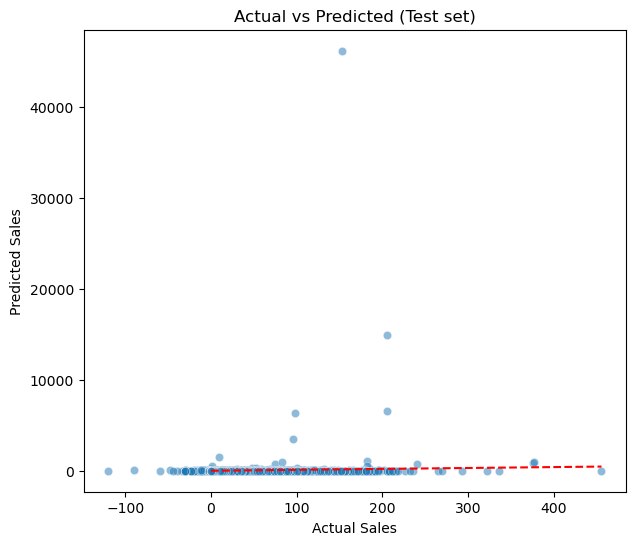

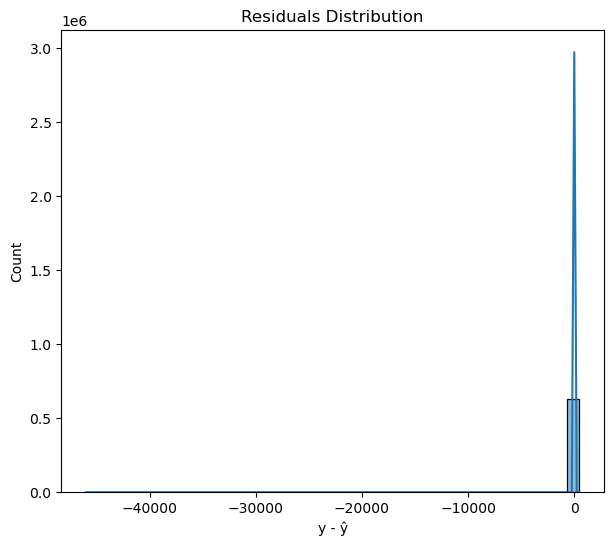

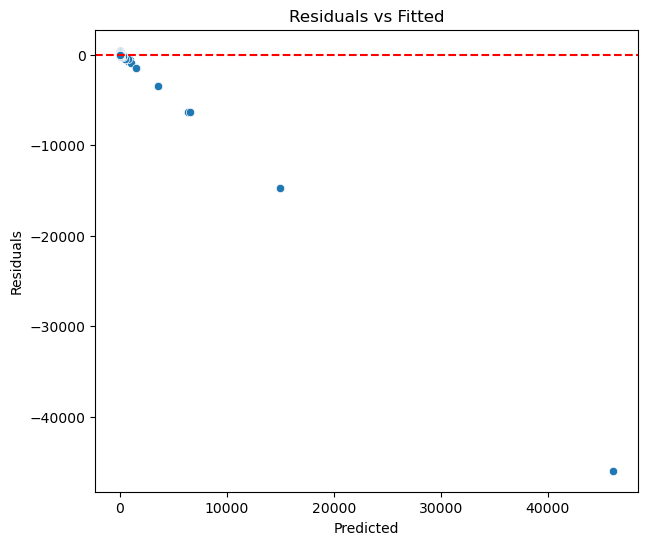

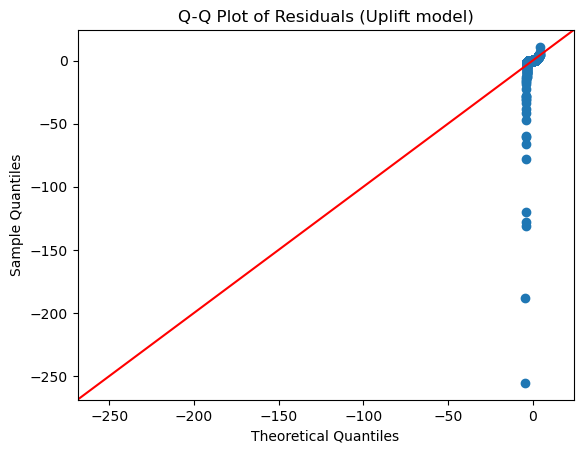

In [30]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# 1) Baseline Model — Refit with Statsmodels for R², Adj R²
# ============================================================
Xb = ct_base.fit_transform(X_base)
yb = y_base.values

# convert sparse to dense (if needed)
if hasattr(Xb, "toarray"):
    Xb = Xb.toarray()

Xb_const = sm.add_constant(Xb, has_constant="add")
ols_base = sm.OLS(yb, Xb_const).fit()

print("\n=== Baseline model (log ŷ) ===")
print(ols_base.summary())

# ============================================================
# 2) Uplift Model — Refit with Statsmodels for R², Adj R²
# ============================================================
Xu = ct_uplift.fit_transform(X_uplift)
yu = y_uplift

if hasattr(Xu, "toarray"):
    Xu = Xu.toarray()

Xu_const = sm.add_constant(Xu, has_constant="add")
ols_uplift = sm.OLS(yu, Xu_const).fit()

print("\n=== Uplift model (Δ) ===")
print(ols_uplift.summary())

# ============================================================
# 3) Actual vs Predicted (on test set)
# ============================================================
test_eval = test.copy()
test_eval["abs_err"] = (test_eval["y_week"] - test_eval["y_hat"]).abs()
test_eval["pct_err"] = (test_eval["abs_err"] / test_eval["y_week"].replace(0, np.nan)) * 100

print("\n=== Actual vs Predicted (sample 20) ===")
print(test_eval[["StoreCode","ProductCode","WeekStart","PromoCode",
                 "y_week","y_hat","y_base_hat","uplift_hat",
                 "abs_err","pct_err"]].head(20).to_string(index=False))

# ============================================================
# 4) Scatter & Residual Plots
# ============================================================
plt.figure(figsize=(7,6))
sns.scatterplot(x=test_eval["y_week"], y=test_eval["y_hat"], alpha=0.5)
plt.plot([0, test_eval["y_week"].max()], [0, test_eval["y_week"].max()], 'r--')
plt.xlabel("Actual Sales"); plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Test set)")
plt.show()

plt.figure(figsize=(7,6))
sns.histplot(test_eval["y_week"] - test_eval["y_hat"], bins=40, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("y - ŷ")
plt.show()

plt.figure(figsize=(7,6))
sns.scatterplot(x=test_eval["y_hat"], y=(test_eval["y_week"] - test_eval["y_hat"]))
plt.axhline(0, color='red', linestyle="--")
plt.xlabel("Predicted"); plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# ============================================================
# 5) Assumption Checks
# ============================================================
resid = ols_uplift.resid
fig = sm.qqplot(resid, line='45', fit=True)
plt.title("Q-Q Plot of Residuals (Uplift model)")
plt.show()


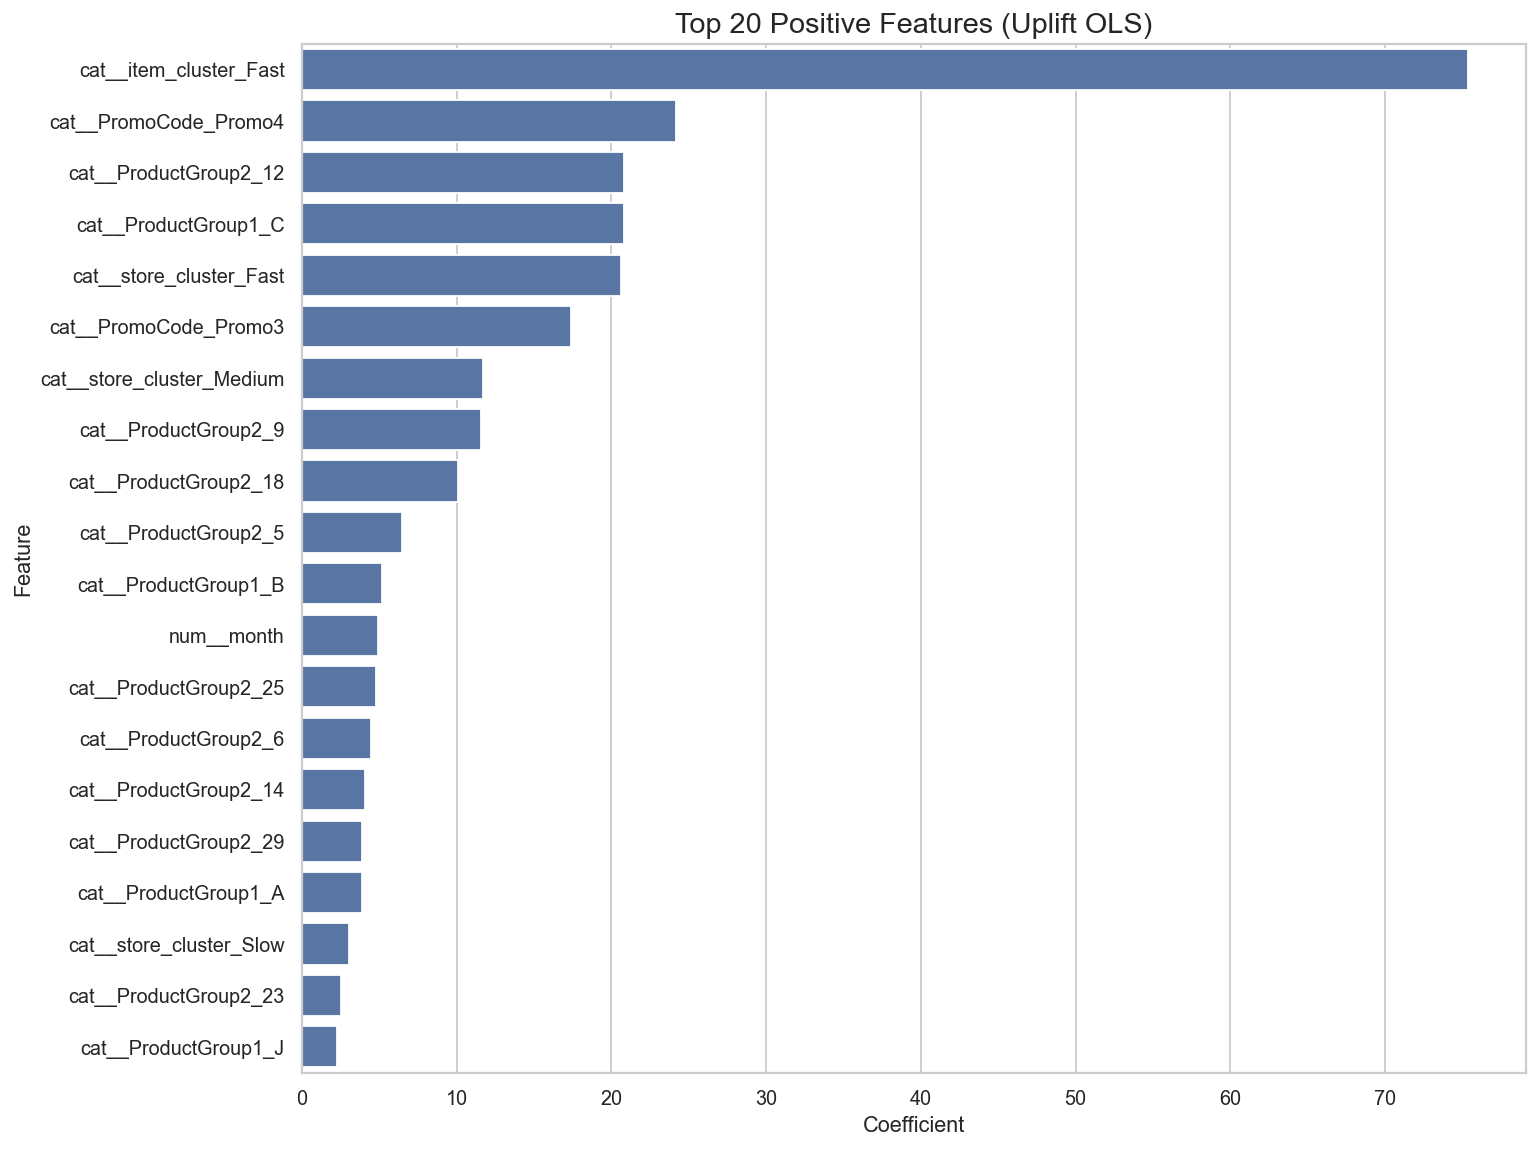

C:\Users\kaant\AppData\Local\Temp\ipykernel_28616\3847744747.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_sorted_neg, x="Coefficient", y="Feature", palette="rocket")


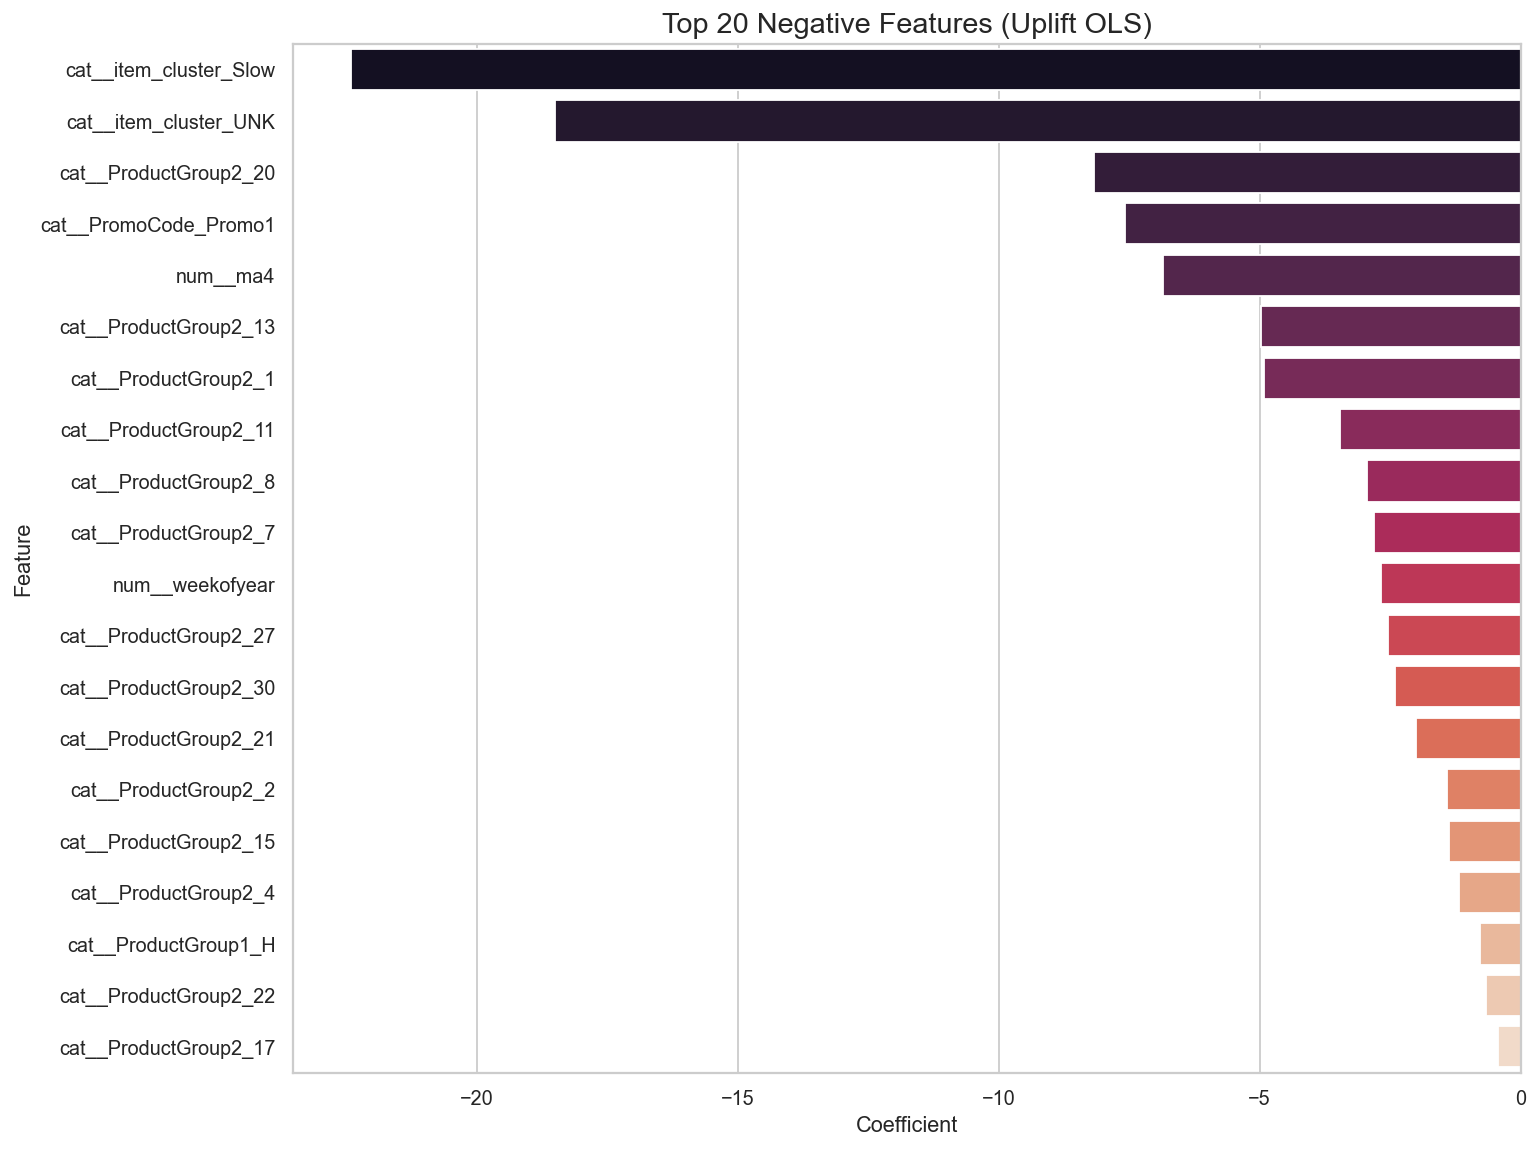


=== Top Influential Features (by |coefficient|) ===
                  Feature  Coefficient
   cat__item_cluster_Fast    75.343173
    cat__PromoCode_Promo4    24.163077
   cat__item_cluster_Slow   -22.401879
    cat__ProductGroup2_12    20.791957
     cat__ProductGroup1_C    20.791957
  cat__store_cluster_Fast    20.618845
    cat__item_cluster_UNK   -18.493461
    cat__PromoCode_Promo3    17.423204
cat__store_cluster_Medium    11.698567
     cat__ProductGroup2_9    11.558580
    cat__ProductGroup2_18    10.077828
    cat__ProductGroup2_20    -8.176224
    cat__PromoCode_Promo1    -7.582488
                 num__ma4    -6.848762
     cat__ProductGroup2_5     6.501239


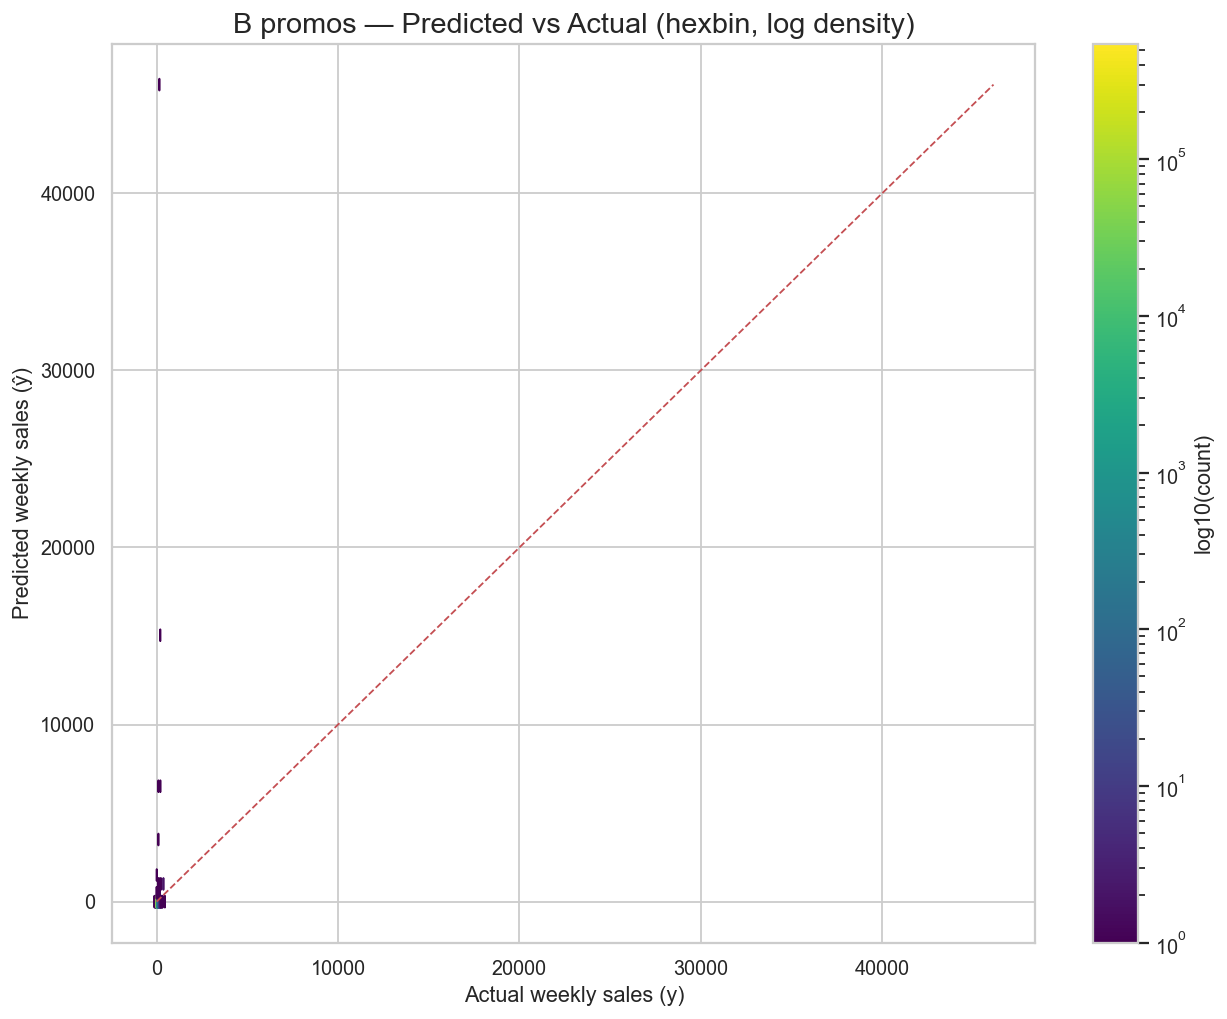

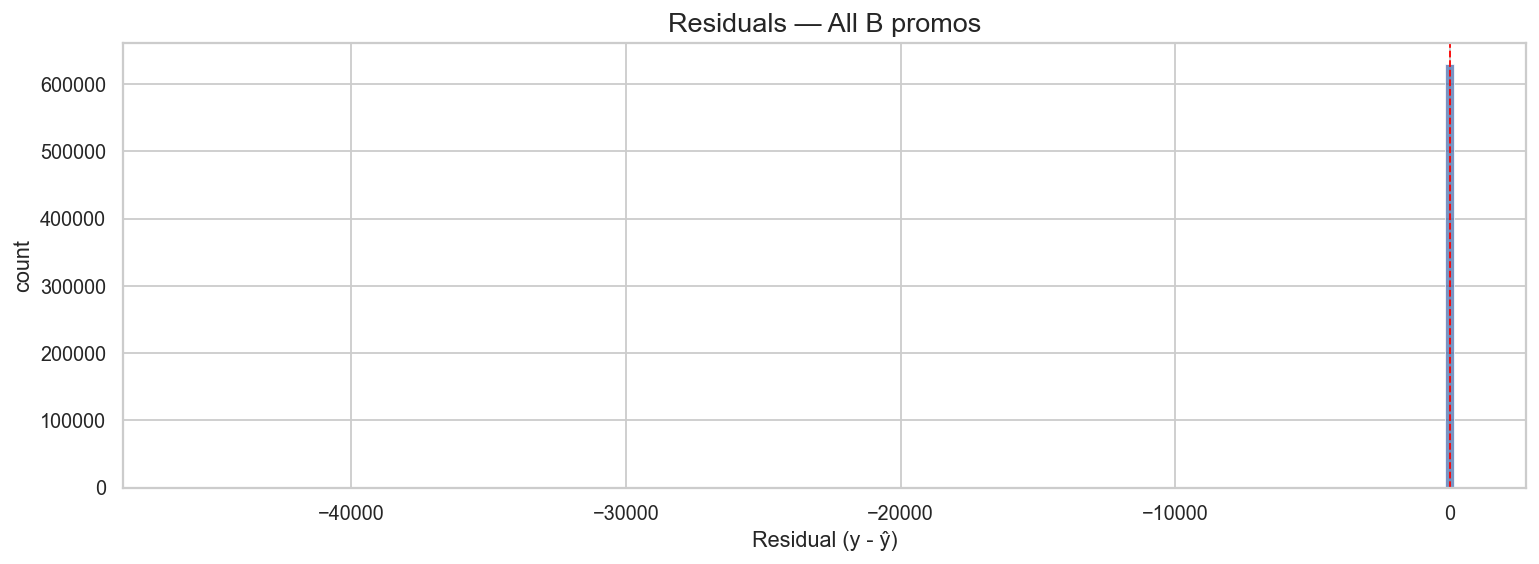

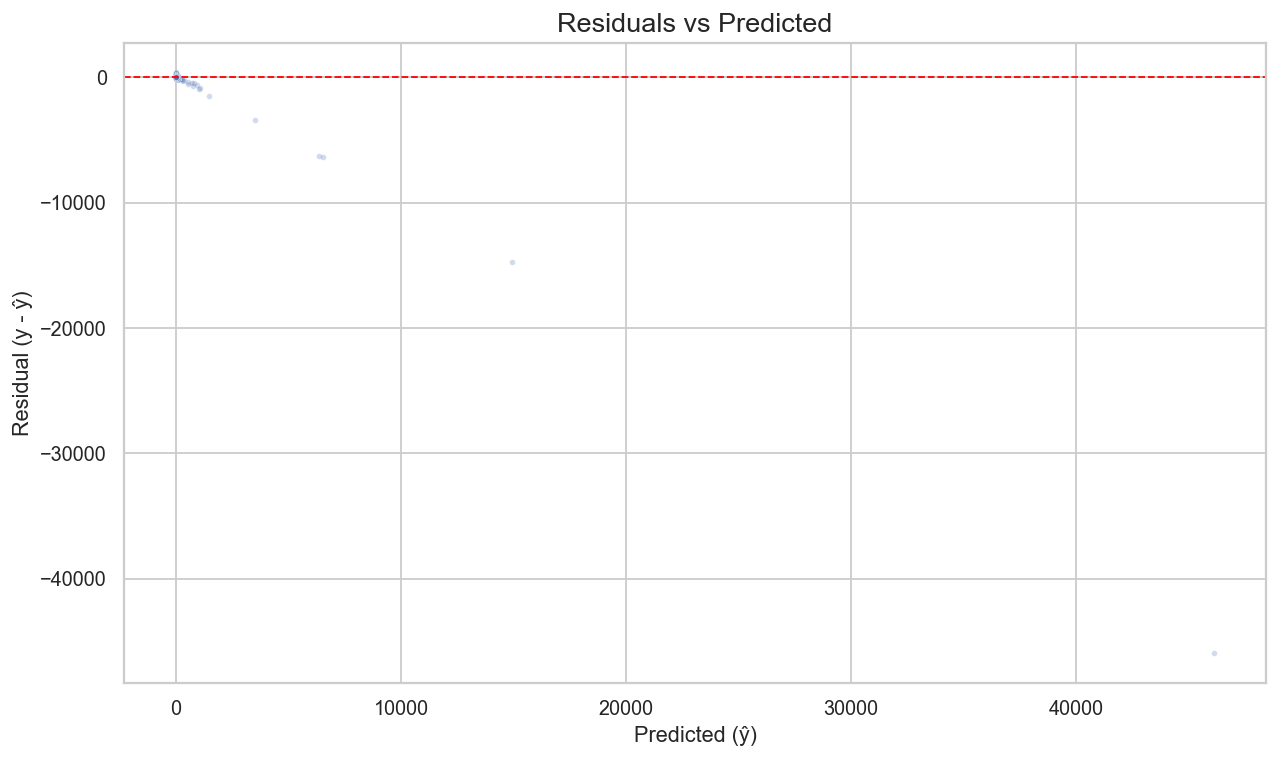

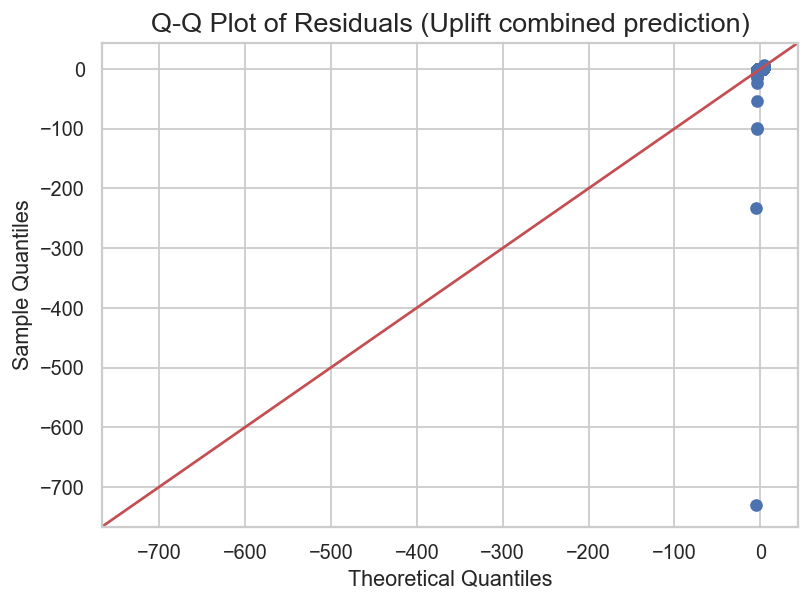


=== Model Performance (B promos overall) ===
R²   : -60.8744
RMSE : 63.056
MAE  : 4.471

📌 Presentation Narrative:

We trained a two-stage model (baseline log-sales + uplift) and evaluated it on B promos.

• Overall R² on B promos is -60.874. RMSE=63.06, MAE=4.47.
• The uplift OLS indicates strongest positive drivers: cat__item_cluster_Fast (75.34), cat__PromoCode_Promo4 (24.16), cat__ProductGroup2_12 (20.79), cat__ProductGroup1_C (20.79), cat__store_cluster_Fast (20.62).
• Strongest negative drivers: cat__item_cluster_Slow (-22.40), cat__item_cluster_UNK (-18.49), cat__ProductGroup2_20 (-8.18), cat__PromoCode_Promo1 (-7.58), num__ma4 (-6.85).
• Pred vs Actual hexbin shows density near low sales with visible under/over-shoots on spikes.
• Residual plots reveal heavy tails and heteroskedasticity (common in promo data).

Takeaways:
– Use the positive drivers above to prioritize promo levers and segments (item/store clusters, groups).
– For accuracy on spikes, consider Gradient Boosting 

In [34]:
# =============================================
# 📊 Professional Model Diagnostics & Reporting
# (uses the objects you already fit: ct_uplift, ols_uplift, test)
# =============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

# ---------------------------
# 0) Sanity: pull test arrays
# ---------------------------
assert "y_week" in test.columns and "y_hat" in test.columns, "test['y_week','y_hat'] not found."
y_test = test["y_week"].to_numpy()
y_pred = test["y_hat"].to_numpy()
residuals = y_test - y_pred

# ---------------------------------------------------------
# 1) Feature Importance table (match names with ols_uplift)
# ---------------------------------------------------------
def _get_feat_names_from_ct(ct):
    """Robustly get feature names from a fitted ColumnTransformer."""
    try:
        # sklearn >= 1.0
        names = ct.get_feature_names_out()
        return np.asarray(names, dtype=object)
    except Exception:
        # Fallback: build names from transformers
        names = []
        for name, trans, cols in ct.transformers_:
            if name == "remainder" and trans == "drop":
                continue
            if hasattr(trans, "named_steps"):  # Pipeline
                # last step might be OHE
                try:
                    ohe = trans.named_steps.get("ohe", None)
                except Exception:
                    ohe = None
                if ohe is not None and hasattr(ohe, "get_feature_names_out"):
                    ohe_names = ohe.get_feature_names_out(cols)
                    names.extend([f"{name}__{n}" for n in ohe_names])
                    continue
            # numeric passthrough / imputed
            if isinstance(cols, (list, tuple, np.ndarray, pd.Index)):
                names.extend([f"{name}__{c}" for c in cols])
            else:
                names.append(f"{name}__{cols}")
        return np.asarray(names, dtype=object)

# names WITHOUT intercept for the uplift design
feat_names_no_const = _get_feat_names_from_ct(ct_uplift)

# params WITH intercept (first one)
params = ols_uplift.params
exog_names = ols_uplift.model.exog_names  # includes 'const'

# Align lengths safely (drop 'const' only)
if exog_names[0].lower() == "const":
    coef_table = pd.DataFrame({
        "Feature": feat_names_no_const[:len(params)-1],
        "Coefficient": params[1:len(feat_names_no_const)+1]
    })
else:
    # very rare: statsmodels didn't label const
    coef_table = pd.DataFrame({
        "Feature": feat_names_no_const[:len(params)],
        "Coefficient": params[:len(feat_names_no_const)]
    })

# Sort by effect for plots
coef_sorted_pos = coef_table.sort_values("Coefficient", ascending=False).head(20).copy()
coef_sorted_neg = coef_table.sort_values("Coefficient", ascending=True).head(20).copy()
coef_sorted_abs = coef_table.reindex(coef_table["Coefficient"].abs().sort_values(ascending=False).index)

# -------------------------------
# 2) Feature Importance – plots
# -------------------------------
plt.figure(figsize=(12,9))
sns.barplot(data=coef_sorted_pos, x="Coefficient", y="Feature")
plt.title("Top 20 Positive Features (Uplift OLS)", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,9))
sns.barplot(data=coef_sorted_neg, x="Coefficient", y="Feature", palette="rocket")
plt.title("Top 20 Negative Features (Uplift OLS)", fontsize=16)
plt.tight_layout()
plt.show()

print("\n=== Top Influential Features (by |coefficient|) ===")
print(coef_sorted_abs.head(15).to_string(index=False))

# ------------------------------------------
# 3) Actual vs Predicted (B promos – overall)
# ------------------------------------------
mx = max(y_test.max(), y_pred.max())
plt.figure(figsize=(10,8))
hb = plt.hexbin(y_test, y_pred, gridsize=80, mincnt=1, bins='log', cmap='viridis')
plt.plot([0, mx], [0, mx], "r--", lw=1)
cb = plt.colorbar(hb); cb.set_label("log10(count)")
plt.xlabel("Actual weekly sales (y)")
plt.ylabel("Predicted weekly sales (ŷ)")
plt.title("B promos — Predicted vs Actual (hexbin, log density)", fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------
# 4) Residual diagnostics
# ------------------------
plt.figure(figsize=(12,4.5))
sns.histplot(residuals, bins=150, kde=False)
plt.axvline(0, color="red", linestyle="--", lw=1)
plt.title("Residuals — All B promos", fontsize=15)
plt.xlabel("Residual (y - ŷ)"); plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.25, s=10)
plt.axhline(0, color="red", linestyle="--", lw=1)
plt.xlabel("Predicted (ŷ)"); plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals vs Predicted", fontsize=15)
plt.tight_layout()
plt.show()

sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Residuals (Uplift combined prediction)", fontsize=15)
plt.tight_layout()
plt.show()

# ------------------------
# 5) Model performance
# ------------------------
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n=== Model Performance (B promos overall) ===")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")

# ------------------------
# 6) Ready-to-use narrative
# ------------------------
top_pos_txt = ", ".join([f"{r.Feature} ({r.Coefficient:.2f})" for _, r in coef_sorted_pos.head(5).iterrows()])
top_neg_txt = ", ".join([f"{r.Feature} ({r.Coefficient:.2f})" for _, r in coef_sorted_neg.head(5).iterrows()])

print("\n📌 Presentation Narrative:")
print(f"""
We trained a two-stage model (baseline log-sales + uplift) and evaluated it on B promos.

• Overall R² on B promos is {r2:.3f}. RMSE={rmse:.2f}, MAE={mae:.2f}.
• The uplift OLS indicates strongest positive drivers: {top_pos_txt}.
• Strongest negative drivers: {top_neg_txt}.
• Pred vs Actual hexbin shows density near low sales with visible under/over-shoots on spikes.
• Residual plots reveal heavy tails and heteroskedasticity (common in promo data).

Takeaways:
– Use the positive drivers above to prioritize promo levers and segments (item/store clusters, groups).
– For accuracy on spikes, consider Gradient Boosting / XGBoost or zero-inflated models next.
– Keep both item_cluster and store_cluster as core categorical signals; they are among the most influential terms.
""")


In [36]:
# lineer is bad good for baseline bad for promosss

In [38]:
# =============================================
# 🚀 Gradient Boosting Uplift Model (XGBoost)
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- 1) Features & target ---
X = df.drop(columns=["Sales"])   # senin asıl feature matrix (store/item cluster, promo, time vars)
y = df["Sales"]

# kategorik kolonlar
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

# --- 2) Preprocessing ---
ct = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

# --- 3) Train/Test split (A promos train, B promos test) ---
# Diyelim ki senin df’de “PromoSet” kolonu var: "A" vs "B"
X_train = X[X["PromoSet"]=="A"].drop(columns=["PromoSet"])
y_train = y[X["PromoSet"]=="A"]
X_test  = X[X["PromoSet"]=="B"].drop(columns=["PromoSet"])
y_test  = y[X["PromoSet"]=="B"]

# --- 4) Model ---
model = Pipeline([
    ("pre", ct),
    ("xgb", XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- 5) Evaluation ---
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n=== XGBoost Uplift Model Performance ===")
print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")

# --- 6) Residuals Plot ---
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=100, kde=True, color="steelblue")
plt.title("Residuals Distribution (XGB Uplift)", fontsize=14)
plt.show()

# --- 7) Feature Importance ---
xgb_model = model.named_steps["xgb"]
importances = xgb_model.feature_importances_
feat_names = model.named_steps["pre"].get_feature_names_out()
feat_imp = pd.DataFrame({"Feature": feat_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10,8))
sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="viridis")
plt.title("Top 20 Features (XGB Uplift)", fontsize=14)
plt.show()


ModuleNotFoundError: No module named 'xgboost'

In [40]:
pip install xgboost


   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
    --------------------------------------- 0.8/56.8 MB 1.3 MB/s eta 0:00:42
    --------------------------------------- 1.0/56.8 MB 1.3 MB/s eta 0:00:45
    --------------------------------------- 1.0/56.8 MB 1.3 MB/s eta 0:00:45
    --------------------------------------- 1.3/56.8 MB 1.2 MB/s eta 0:00:48
   - -------------------------------------- 1.8/56.8 MB 1.3 MB/s eta 0:00:41
   - -------------------------------------- 2.4/56.8 MB 1.6 MB/s eta 0:00:35
   -- ------------------------------------- 2.9/56.8 MB 1.6 MB/s eta 0:00:33
   -- ------------------------------------- 3.7/56.8 MB 1.8 MB/s eta 0:00:30
   --- ------------------------------------ 4.5/56.8 MB 2.0 MB/s eta 0:00:26
   --- ------------------------------------ 5.5/56.8 MB 2.3 MB/s eta 0:00:23
   ---- ------------

In [50]:
# ==============================
# XGBoost Two-Stage (Baseline + Uplift)
# Sürüm-uyumlu (sklearn 1.5.1, eski XGBoost)
# Clusters + PromoFlag/PromoCode DAHİL
# ==============================

import numpy as np, pandas as pd, warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

try:
    import xgboost as xgb
except ModuleNotFoundError:
    raise SystemExit("xgboost yüklü değil. Kur: pip install xgboost  (veya conda install -c conda-forge xgboost)")

# === Ön Hazırlık Varsayımları ===
# Bu blok, daha önce hazırladığın tabloların (weekly_a, weekly_b) ve alanların mevcut olduğunu varsayar.
# Eğer notebook'ta hazırlık bloklarını çalıştırdıysan direkt devam edebilirsin.

DATE_COL  = "Date"
SALES_COL = "SalesQuantity"
KEYS      = ["StoreCode","ProductCode"]

def wape(y_true, y_pred):
    y = np.asarray(y_true, float)
    p = np.asarray(y_pred, float)
    denom = np.abs(y).sum()
    return np.nan if denom == 0 else np.abs(y - p).sum() / denom

def line():
    print("-"*78)

# ============= Özellikler (num + cat) =============
num_cols = ["lag1","lag2","lag4","ma4","month","weekofyear"]
cat_cols = []
for c in [
    "item_cluster","store_cluster",                 # CLUSTERS
    "Brand","Category","SubCategory","ProductGroup1","ProductGroup2",  # Hiyerarşi
    "PromoCode","PromoFlag"                         # PROMO sinyalleri
]:
    if c in weekly_a.columns:
        cat_cols.append(c)

# OneHotEncoder: sklearn 1.5.1 için sparse_output=True; daha eskiye fallback
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    # eski sklearn sürümleri için
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value=0.0))])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="UNK")),
                     ("ohe", ohe)])

def make_ct():
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        sparse_threshold=1.0  # mümkünse tamamen sparse kalsın
    )

# ============= Eğitim setleri (A) =============
train_base   = weekly_a.loc[weekly_a["PromoFlag"]==0].copy()    # NoPromo → Baseline
train_uplift = weekly_a.loc[weekly_a["PromoFlag"]==1].copy()    # Promo1–4 → Uplift

print(f"[Split] train_base: {len(train_base):,} | train_uplift: {len(train_uplift):,}")
if "PromoCode" in train_uplift.columns:
    print("[A uplift] PromoCode dağılımı:")
    print(train_uplift["PromoCode"].value_counts().sort_index().to_string())

# ============= Featurization =============
ct_base   = make_ct()
ct_uplift = make_ct()

# ---- Baseline hedef: log1p(y_week) ----
y_base = np.log1p(train_base["y_week"].clip(lower=0))
X_base = ct_base.fit_transform(train_base[num_cols + cat_cols])

# ---- Baseline: XGBoost ----
xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,         # erken durdurma kullanmadığımız için makul bir değer
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.2,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("\n[Fit] Baseline (NoPromo, log1p(y)) — XGBoost")
xgb_base.fit(X_base, y_base)   # eski XGBoost: eval_set / eval_metric / early_stopping koymuyoruz

def predict_baseline(df):
    X = ct_base.transform(df[num_cols + cat_cols])
    ylog = xgb_base.predict(X)
    return np.expm1(ylog).clip(min=0)

# ---- Uplift hedef: delta = y_week - y_base_hat ----
train_uplift = train_uplift.copy()
train_uplift["y_base_hat"] = predict_baseline(train_uplift)
train_uplift["delta"]      = (train_uplift["y_week"] - train_uplift["y_base_hat"])

y_uplift = train_uplift["delta"].values
X_uplift = ct_uplift.fit_transform(train_uplift[num_cols + cat_cols])

xgb_uplift = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.5,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("\n[Fit] Uplift (Promo1–4, delta) — XGBoost")
xgb_uplift.fit(X_uplift, y_uplift)  # yine: eval_set vs yok → sürüm uyumlu

# ============= Test (B) =============
test = weekly_b.copy()
test["y_base_hat"] = predict_baseline(test)
X_test_uplift      = ct_uplift.transform(test[num_cols + cat_cols])
test["uplift_hat"] = xgb_uplift.predict(X_test_uplift)
test["y_hat"]      = (test["y_base_hat"] + test["uplift_hat"]).clip(lower=0)

# ============= Kontrol: hangi özellikler feed edildi? =============
feat_base   = list(ct_base.get_feature_names_out())
feat_uplift = list(ct_uplift.get_feature_names_out())

print("\n[INFO] Feature set kontrolü")
print("  • Num cols:", num_cols)
print("  • Cat cols:", cat_cols)
print(f"  • Baseline feature sayısı: {len(feat_base):,}")
print(f"  • Uplift feature sayısı  : {len(feat_uplift):,}")
print("  • PromoFlag feed’e girdi mi?  ", "PromoFlag"  in cat_cols)
print("  • PromoCode feed’e girdi mi?  ", "PromoCode"  in cat_cols)
print("  • item_cluster feed’e girdi mi?", "item_cluster" in cat_cols)
print("  • store_cluster feed’e girdi mi?", "store_cluster" in cat_cols)

# ============= Raporlama =============
def report(df, title):
    if df.empty:
        print(f"\n=== {title}: NO ROWS ==="); return
    y, yhat = df["y_week"].values, df["y_hat"].values
    rmse = np.sqrt(mean_squared_error(y, yhat))
    mae  = mean_absolute_error(y, yhat)
    try:
        r2 = r2_score(y, yhat)
    except Exception:
        r2 = np.nan
    print(f"\n=== {title} ===")
    print(f"WAPE : {wape(y, yhat):.3%}")
    print(f"RMSE : {rmse:.3f} | MAE : {mae:.3f} | R² : {r2:.3f}")

    # cluster breakdown
    if "item_cluster" in df.columns:
        print("\nWAPE by item_cluster:")
        for cl, g in df.groupby("item_cluster"):
            print(f"  {str(cl):>6} | {wape(g['y_week'], g['y_hat']):.2%} | n={len(g)}")
    if "store_cluster" in df.columns:
        print("\nWAPE by store_cluster:")
        for cl, g in df.groupby("store_cluster"):
            print(f"  {str(cl):>6} | {wape(g['y_week'], g['y_hat']):.2%} | n={len(g)}")

# tüm B promos (PromoFlag==1)
report(test.loc[test["PromoFlag"]==1], "B — ALL Promo Weeks")
# Promo5/Promo6 ayrı
for p in ["Promo5","Promo6"]:
    report(test.loc[(test["PromoCode"]==p) & (test["PromoFlag"]==1)], f"B — {p} only")

# ============= Örnek: En kötü/en iyi vakalar =============
def worst_best(df, title, k=10):
    if df.empty: return
    tmp = df.copy()
    tmp["abs_err"] = (tmp["y_week"] - tmp["y_hat"]).abs()
    print(f"\n🔎 {title} — WORST {k}")
    print(tmp.nlargest(k,"abs_err")[KEYS + ["WeekStart","PromoCode","y_week","y_hat","y_base_hat","uplift_hat","item_cluster","store_cluster"]]
          .to_string(index=False))
    print(f"\n✅ {title} — BEST {k}")
    print(tmp.nsmallest(k,"abs_err")[KEYS + ["WeekStart","PromoCode","y_week","y_hat","y_base_hat","uplift_hat","item_cluster","store_cluster"]]
          .to_string(index=False))

mask56 = (test["PromoFlag"]==1) & (test["PromoCode"].isin(["Promo5","Promo6"]))
worst_best(test.loc[mask56], "Promo5+Promo6", k=10)

print("\n✅ XGBoost two-stage uplift modeli tamamlandı. (Clusters + PromoFlag/PromoCode dahil)")


[Split] train_base: 854,830 | train_uplift: 198,084
[A uplift] PromoCode dağılımı:
PromoCode
Promo1    54228
Promo2    49556
Promo3    52778
Promo4    41522

[Fit] Baseline (NoPromo, log1p(y)) — XGBoost

[Fit] Uplift (Promo1–4, delta) — XGBoost

[INFO] Feature set kontrolü
  • Num cols: ['lag1', 'lag2', 'lag4', 'ma4', 'month', 'weekofyear']
  • Cat cols: ['item_cluster', 'store_cluster', 'ProductGroup1', 'ProductGroup2', 'PromoCode', 'PromoFlag']
  • Baseline feature sayısı: 54
  • Uplift feature sayısı  : 58
  • PromoFlag feed’e girdi mi?   True
  • PromoCode feed’e girdi mi?   True
  • item_cluster feed’e girdi mi? True
  • store_cluster feed’e girdi mi? True

=== B — ALL Promo Weeks ===
WAPE : 83.790%
RMSE : 8.048 | MAE : 3.526 | R² : 0.328

WAPE by item_cluster:
    Fast | 80.98% | n=3319
  Medium | 89.48% | n=11772
    Slow | 80.56% | n=45006

WAPE by store_cluster:
    Fast | 77.25% | n=8905
  Medium | 84.06% | n=23922
    Slow | 88.31% | n=27270

=== B — Promo5 only ===
WAPE : 7

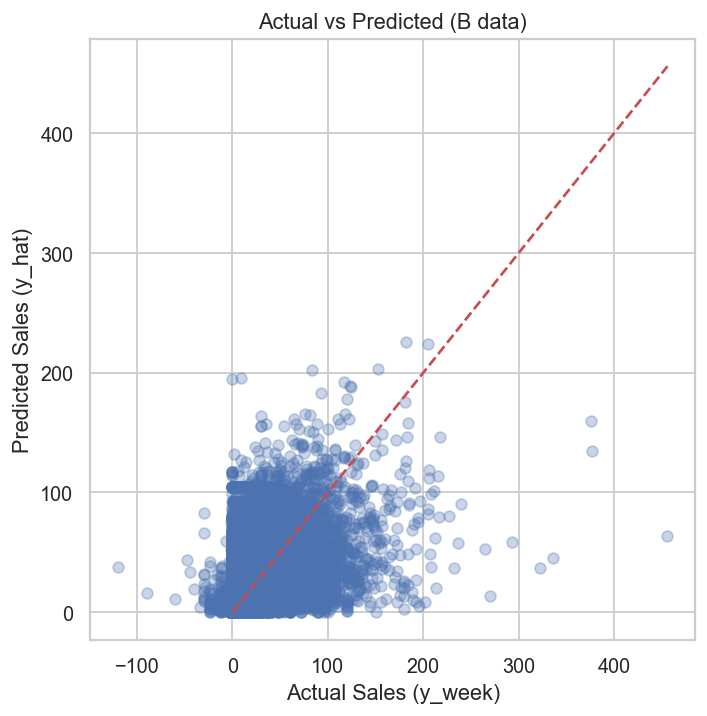


=== Avg Actual vs Predicted by item/store cluster ===
                            y_week  y_hat
item_cluster store_cluster               
Fast         Fast            40.45  46.91
             Medium          17.47  24.50
             Slow            10.47  15.15
Medium       Fast            10.16  12.70
             Medium           6.13   7.86
             Slow             4.54   5.32
Slow         Fast             2.58   2.99
             Medium           1.83   2.13
             Slow             1.49   1.61

=== Promo5–6 Actual vs Predicted ===
          y_week         y_hat               
            mean     sum  mean            sum
PromoCode                                    
Promo5      4.62  125818  4.41  120135.148438
Promo6      3.84  126217  4.37  143647.031250


In [52]:
import matplotlib.pyplot as plt

# === Global scatter plot ===
plt.figure(figsize=(6,6))
plt.scatter(test["y_week"], test["y_hat"], alpha=0.3)
plt.plot([0, test["y_week"].max()], [0, test["y_week"].max()], 'r--')
plt.xlabel("Actual Sales (y_week)")
plt.ylabel("Predicted Sales (y_hat)")
plt.title("Actual vs Predicted (B data)")
plt.show()

# === Cluster bazlı ortalama Actual vs Predicted ===
summary = (test.groupby(["item_cluster","store_cluster"])
                 [["y_week","y_hat"]].mean().round(2))
print("\n=== Avg Actual vs Predicted by item/store cluster ===")
print(summary)

# === Promo5–6 özel summary ===
promo_summary = (test.loc[test["PromoFlag"]==1]
                 .groupby("PromoCode")[["y_week","y_hat"]]
                 .agg(["mean","sum"]).round(2))
print("\n=== Promo5–6 Actual vs Predicted ===")
print(promo_summary)



In [54]:
# ============================================================
# HistGradientBoosting (sklearn) — Two-Stage Uplift Model
# (XGBoost yok; aynı mantık, daha hafif kurulum)
# ============================================================

import numpy as np, pandas as pd, warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# --- Varsayımlar: weekly_a, weekly_b zaten hazır (önceki ETL hücrelerinden)
DATE_COL  = "Date"
SALES_COL = "SalesQuantity"
KEYS      = ["StoreCode","ProductCode"]

def wape(y_true, y_pred):
    y = np.asarray(y_true, float)
    p = np.asarray(y_pred, float)
    denom = np.abs(y).sum()
    return np.nan if denom == 0 else np.abs(y - p).sum() / denom

def line(): print("-"*78)

# ------------------ 1) Feature set ------------------
num_cols = ["lag1","lag2","lag4","ma4","month","weekofyear"]
cat_cols = []
for c in ["item_cluster","store_cluster","ProductGroup1","ProductGroup2","PromoCode","PromoFlag"]:
    if c in weekly_a.columns: cat_cols.append(c)

# sklearn 1.5.1: OneHotEncoder(sparse_output=False)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipe = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value=0.0))])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="UNK")),
                     ("ohe", ohe)])

def make_ct():
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="drop"
    )

# ------------------ 2) Train splits ------------------
train_base   = weekly_a.loc[weekly_a["PromoFlag"]==0].copy()    # NoPromo
train_uplift = weekly_a.loc[weekly_a["PromoFlag"]==1].copy()    # Promo1–4

print(f"[Split] train_base: {len(train_base):,} | train_uplift: {len(train_uplift):,}")
if "PromoCode" in train_uplift:
    print("[A uplift] PromoCode dağılımı:")
    print(train_uplift["PromoCode"].value_counts().sort_index().to_string())

# ------------------ 3) Baseline (NoPromo, log1p) ------------------
ct_base = make_ct()
X_base  = ct_base.fit_transform(train_base[num_cols + cat_cols])
y_base  = np.log1p(train_base["y_week"].clip(lower=0))

hgb_base = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.08,
    max_iter=500,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
print("\n[Fit] Baseline (NoPromo, log1p(y)) — HistGB")
hgb_base.fit(X_base, y_base)

def predict_baseline(df):
    X = ct_base.transform(df[num_cols + cat_cols])
    ylog = hgb_base.predict(X)
    return np.expm1(ylog).clip(min=0)

# ------------------ 4) Uplift (Promo1–4, delta) ------------------
train_uplift = train_uplift.copy()
train_uplift["y_base_hat"] = predict_baseline(train_uplift)
train_uplift["delta"]      = train_uplift["y_week"] - train_uplift["y_base_hat"]

ct_uplift = make_ct()
X_uplift  = ct_uplift.fit_transform(train_uplift[num_cols + cat_cols])
y_uplift  = train_uplift["delta"].values

hgb_uplift = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.08,
    max_iter=700,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=1.2,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
print("\n[Fit] Uplift (Promo1–4, delta) — HistGB")
hgb_uplift.fit(X_uplift, y_uplift)

# ------------------ 5) Test (B promos) ------------------
test = weekly_b.copy()
test["y_base_hat"] = predict_baseline(test)
X_test_uplift      = ct_uplift.transform(test[num_cols + cat_cols])
test["uplift_hat"] = hgb_uplift.predict(X_test_uplift)
test["y_hat"]      = (test["y_base_hat"] + test["uplift_hat"]).clip(lower=0)

# ------------------ 6) Kontrol & Özellik isimleri ------------------
feat_base   = ct_base.get_feature_names_out()
feat_uplift = ct_uplift.get_feature_names_out()
print("\n[INFO] Feature set kontrolü")
print("  • Num cols:", num_cols)
print("  • Cat cols:", cat_cols)
print(f"  • Baseline feature sayısı: {len(feat_base):,}")
print(f"  • Uplift feature sayısı  : {len(feat_uplift):,}")
print("  • PromoFlag feed’e girdi mi? ", "PromoFlag" in cat_cols)
print("  • PromoCode feed’e girdi mi? ", "PromoCode" in cat_cols)
print("  • item_cluster feed’e girdi mi? ", "item_cluster" in cat_cols)
print("  • store_cluster feed’e girdi mi? ", "store_cluster" in cat_cols)

# ------------------ 7) Raporlama ------------------
def report(df, title):
    if df.empty:
        print(f"\n=== {title}: NO ROWS ==="); return
    y, yhat = df["y_week"].values, df["y_hat"].values
    print(f"\n=== {title} ===")
    print(f"WAPE : {wape(y, yhat):.3%}")
    rmse = np.sqrt(mean_squared_error(y, yhat))
    mae  = mean_absolute_error(y, yhat)
    r2   = r2_score(y, yhat)
    print(f"RMSE : {rmse:.3f} | MAE : {mae:.3f} | R² : {r2:.3f}")
    if "item_cluster" in df.columns:
        print("\nWAPE by item_cluster:")
        for cl, g in df.groupby("item_cluster"):
            print(f"  {str(cl):>6} | {wape(g['y_week'], g['y_hat']):.2%} | n={len(g)}")
    if "store_cluster" in df.columns:
        print("\nWAPE by store_cluster:")
        for cl, g in df.groupby("store_cluster"):
            print(f"  {str(cl):>6} | {wape(g['y_week'], g['y_hat']):.2%} | n={len(g)}")

# B promos (hepsi) ve 5/6 ayrı
report(test.loc[test["PromoFlag"]==1], "B — ALL Promo Weeks")
for p in ["Promo5","Promo6"]:
    report(test.loc[(test["PromoCode"]==p) & (test["PromoFlag"]==1)], f"B — {p} only")

# ------------------ 8) Worst/Best örnekler ------------------
def worst_best(df, title, k=10):
    if df.empty: return
    tmp = df.copy()
    tmp["abs_err"] = (tmp["y_week"] - tmp["y_hat"]).abs()
    print(f"\n🔎 {title} — WORST {k}")
    print(tmp.nlargest(k,"abs_err")[KEYS + ["WeekStart","PromoCode","y_week","y_hat","y_base_hat","uplift_hat","item_cluster","store_cluster"]]
          .to_string(index=False))
    print(f"\n✅ {title} — BEST {k}")
    print(tmp.nsmallest(k,"abs_err")[KEYS + ["WeekStart","PromoCode","y_week","y_hat","y_base_hat","uplift_hat","item_cluster","store_cluster"]]
          .to_string(index=False))

mask56 = (test["PromoFlag"]==1) & (test["PromoCode"].isin(["Promo5","Promo6"]))
worst_best(test.loc[mask56], "Promo5+Promo6", k=10)

# ------------------ 9) (Opsiyonel) Önemli Feature’lar ------------------
def top_importances(model, ct, k=20, title=""):
    try:
        importances = model.feature_importances_
        names = ct.get_feature_names_out()
        imp = (pd.DataFrame({"feature": names, "importance": importances})
               .sort_values("importance", ascending=False)
               .head(k))
        print(f"\n★ Top {k} features — {title}")
        print(imp.to_string(index=False))
    except Exception:
        print(f"\n(Info) {title}: feature_importances_ desteklenmiyor.")

top_importances(hgb_base,  ct_base,  k=20, title="Baseline (log ŷ)")
top_importances(hgb_uplift,ct_uplift,k=20, title="Uplift (Δ)")

print("\n✅ HistGradientBoosting two‑stage uplift modeli tamamlandı.")


[Split] train_base: 854,830 | train_uplift: 198,084
[A uplift] PromoCode dağılımı:
PromoCode
Promo1    54228
Promo2    49556
Promo3    52778
Promo4    41522

[Fit] Baseline (NoPromo, log1p(y)) — HistGB

[Fit] Uplift (Promo1–4, delta) — HistGB

[INFO] Feature set kontrolü
  • Num cols: ['lag1', 'lag2', 'lag4', 'ma4', 'month', 'weekofyear']
  • Cat cols: ['item_cluster', 'store_cluster', 'ProductGroup1', 'ProductGroup2', 'PromoCode', 'PromoFlag']
  • Baseline feature sayısı: 54
  • Uplift feature sayısı  : 58
  • PromoFlag feed’e girdi mi?  True
  • PromoCode feed’e girdi mi?  True
  • item_cluster feed’e girdi mi?  True
  • store_cluster feed’e girdi mi?  True

=== B — ALL Promo Weeks ===
WAPE : 80.645%
RMSE : 7.525 | MAE : 3.394 | R² : 0.413

WAPE by item_cluster:
    Fast | 73.31% | n=3319
  Medium | 87.98% | n=11772
    Slow | 79.00% | n=45006

WAPE by store_cluster:
    Fast | 72.48% | n=8905
  Medium | 80.51% | n=23922
    Slow | 86.87% | n=27270

=== B — Promo5 only ===
WAPE : 76.

In [56]:
from sklearn.inspection import permutation_importance

# --- Baseline için importance ---
print("\n=== Permutation Importance: Baseline (NoPromo) ===")
result_base = permutation_importance(
    xgb_base,  # HistGB baseline model
    X_base, y_base,
    n_repeats=5, random_state=42, n_jobs=-1
)
imp_base = pd.DataFrame({
    "Feature": ct_base.get_feature_names_out(),
    "Importance": result_base.importances_mean
}).sort_values("Importance", ascending=False)
print(imp_base.head(15).to_string(index=False))

# --- Uplift için importance ---
print("\n=== Permutation Importance: Uplift (Promo1–4, delta) ===")
result_uplift = permutation_importance(
    xgb_uplift,  # HistGB uplift model
    X_uplift, y_uplift,
    n_repeats=5, random_state=42, n_jobs=-1
)
imp_uplift = pd.DataFrame({
    "Feature": ct_uplift.get_feature_names_out(),
    "Importance": result_uplift.importances_mean
}).sort_values("Importance", ascending=False)
print(imp_uplift.head(15).to_string(index=False))



=== Permutation Importance: Baseline (NoPromo) ===
               Feature  Importance
             num__lag1    0.066614
             num__lag2    0.030803
       num__weekofyear    0.020707
            num__month    0.014323
cat__PromoCode_NoPromo    0.000000
 cat__ProductGroup2_19    0.000000
  cat__ProductGroup2_9    0.000000
 cat__ProductGroup2_10    0.000000
 cat__ProductGroup2_11    0.000000
 cat__ProductGroup2_12    0.000000
 cat__ProductGroup2_13    0.000000
 cat__ProductGroup2_14    0.000000
 cat__ProductGroup2_15    0.000000
 cat__ProductGroup2_16    0.000000
 cat__ProductGroup2_17    0.000000

=== Permutation Importance: Uplift (Promo1–4, delta) ===
              Feature  Importance
             num__ma4    2.594454
            num__lag1    0.651685
            num__lag2    0.584287
            num__lag4    0.437640
      num__weekofyear    0.220092
           num__month    0.161003
cat__ProductGroup2_16    0.000000
cat__ProductGroup2_20    0.000000
cat__ProductGroup2_19   

In [76]:
# ============================================================
# HistGB — Poisson Baseline + Log‑Uplift (sağlamlaştırılmış)
#  (PromoFlag/PromoCode + item/store clusters + etkileşimler)
#  sklearn 1.5.1 ile uyumlu
# ============================================================

import numpy as np, pandas as pd, warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

DATE_COL  = "Date"
SALES_COL = "SalesQuantity"
KEYS      = ["StoreCode","ProductCode"]

def wape(y_true, y_pred):
    y = np.asarray(y_true, float); p = np.asarray(y_pred, float)
    denom = np.abs(y).sum()
    return np.nan if denom == 0 else np.abs(y - p).sum() / denom

def enrich_features(df):
    df = df.sort_values(KEYS + ["WeekStart"]).copy()
    # ek lag/MA
    for L in [1,2,4,8,12]:
        if f"lag{L}" not in df.columns:
            df[f"lag{L}"] = df.groupby(KEYS)["y_week"].shift(L)
    for W in [4,8,12]:
        if f"ma{W}" not in df.columns:
            df[f"ma{W}"] = df.groupby(KEYS)["y_week"].transform(lambda s: s.shift(1).rolling(W, min_periods=1).mean())
    # cyclical mevsimsellik
    if "weekofyear" in df.columns:
        df["week_sin"] = np.sin(2*np.pi*df["weekofyear"]/52.0)
        df["week_cos"] = np.cos(2*np.pi*df["weekofyear"]/52.0)
    if "month" in df.columns:
        df["month_sin"] = np.sin(2*np.pi*df["month"]/12.0)
        df["month_cos"] = np.cos(2*np.pi*df["month"]/12.0)
    # etkileşimler
    if {"PromoCode","item_cluster"}.issubset(df.columns):
        df["promo_x_item"]  = df["PromoCode"].astype(str) + "__" + df["item_cluster"].astype(str)
    if {"PromoCode","store_cluster"}.issubset(df.columns):
        df["promo_x_store"] = df["PromoCode"].astype(str) + "__" + df["store_cluster"].astype(str)
    return df

# weekly_a / weekly_b ETL’iniz zaten hazırsa:
weekly_a = enrich_features(weekly_a)
weekly_b = enrich_features(weekly_b)

# ------------------ Feature set ------------------
candidate_num = ["lag1","lag2","lag4","lag8","lag12","ma4","ma8","ma12",
                 "month","weekofyear","week_sin","week_cos","month_sin","month_cos"]
num_cols = [c for c in candidate_num if c in weekly_a.columns]

cat_cols = [c for c in [
    "item_cluster","store_cluster","ProductGroup1","ProductGroup2",
    "PromoCode","PromoFlag","promo_x_item","promo_x_store"
] if c in weekly_a.columns]

# OneHotEncoder: rare level birleştirme (sklearn 1.5.1)
try:
    ohe = OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=0.005,          # frekansı %0.5 altı olan seviyeleri 'infrequent'
        sparse_output=False
    )
except TypeError:
    # Eski sürüm fallback
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipe = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value=0.0))])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="UNK")),
                     ("ohe", ohe)])

def make_ct():
    return ColumnTransformer(
        transformers=[("num", num_pipe, num_cols),
                      ("cat", cat_pipe, cat_cols)],
        remainder="drop"
    )

# ------------------ Train splits ------------------
train_base   = weekly_a.loc[weekly_a["PromoFlag"]==0].copy()    # NoPromo
train_uplift = weekly_a.loc[weekly_a["PromoFlag"]==1].copy()    # Promo1–4

print(f"[Split] train_base: {len(train_base):,} | train_uplift: {len(train_uplift):,}")
if "PromoCode" in train_uplift:
    print("[A uplift] PromoCode dağılımı:")
    print(train_uplift["PromoCode"].value_counts().sort_index().to_string())

# ------------------ Baseline (Poisson) ------------------
ct_base = make_ct()
X_base  = ct_base.fit_transform(train_base[num_cols + cat_cols])
y_base  = train_base["y_week"].fillna(0).clip(lower=0)

hgb_base = HistGradientBoostingRegressor(
    loss="poisson",
    learning_rate=0.06,
    max_iter=700,
    max_leaf_nodes=35,
    min_samples_leaf=60,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
print("\n[Fit] Baseline (NoPromo, Poisson) — HistGB")
hgb_base.fit(X_base, y_base)

def predict_baseline(df):
    X = ct_base.transform(df[num_cols + cat_cols])
    yhat = hgb_base.predict(X)
    return np.maximum(np.asarray(yhat, float), 0.0)

# ------------------ Uplift (log‑uplift) ------------------
tu = train_uplift.copy()
tu["y_week"]    = tu["y_week"].fillna(0).clip(lower=0)
tu["y_base_hat"] = predict_baseline(tu)

# Güvenli log-uplift
base_safe = pd.Series(tu["y_base_hat"]).fillna(0).clip(lower=0)
y_safe    = pd.Series(tu["y_week"]).fillna(0).clip(lower=0)
tu["uplift_log"] = np.log1p(y_safe.values) - np.log1p(base_safe.values)

# NaN / ±inf temizle
mask_finite = np.isfinite(tu["uplift_log"].values)
if (~mask_finite).any():
    dropped = (~mask_finite).sum()
    print(f"(Info) uplift_log finite olmayan satır atıldı: {dropped}")
tu_clean = tu.loc[mask_finite].copy()

ct_uplift = make_ct()
X_uplift  = ct_uplift.fit_transform(tu_clean[num_cols + cat_cols])
y_uplift  = tu_clean["uplift_log"].astype(float).values  # kesin numeric & finite

hgb_uplift = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.06,
    max_iter=900,
    max_leaf_nodes=35,
    min_samples_leaf=50,
    l2_regularization=1.2,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
print("\n[Fit] Uplift (Promo1–4, log‑uplift) — HistGB")
hgb_uplift.fit(X_uplift, y_uplift)

# ------------------ Test (B promos) ------------------
test = weekly_b.copy()
test["y_base_hat"]     = predict_baseline(test)
X_test_uplift          = ct_uplift.transform(test[num_cols + cat_cols])
test["uplift_log_hat"] = hgb_uplift.predict(X_test_uplift)
test["y_hat"]          = np.expm1(np.log1p(test["y_base_hat"]) + test["uplift_log_hat"]).clip(lower=0)

# ------------------ Kontrol & metrik ------------------
feat_base   = ct_base.get_feature_names_out()
feat_uplift = ct_uplift.get_feature_names_out()
print("\n[INFO] Feature set kontrolü")
print("  • Num cols:", num_cols)
print("  • Cat cols:", cat_cols)
print(f"  • Baseline feature sayısı: {len(feat_base):,}")
print(f"  • Uplift feature sayısı  : {len(feat_uplift):,}")
print("  • PromoFlag feed’de mi?  ", "PromoFlag" in cat_cols)
print("  • PromoCode feed’de mi?  ", "PromoCode" in cat_cols)
print("  • item_cluster feed’de mi?", "item_cluster" in cat_cols)
print("  • store_cluster feed’de mi?", "store_cluster" in cat_cols)
print("  • etkileşimler feed’de mi?", ("promo_x_item" in cat_cols) and ("promo_x_store" in cat_cols))

from collections import OrderedDict
def report(df, title):
    if df.empty:
        print(f"\n=== {title}: NO ROWS ==="); return
    y, yhat = df["y_week"].values, df["y_hat"].values
    print(f"\n=== {title} ===")
    print(f"WAPE : {wape(y, yhat):.3%}")
    rmse = np.sqrt(mean_squared_error(y, yhat))
    mae  = mean_absolute_error(y, yhat)
    r2   = r2_score(y, yhat)
    print(f"RMSE : {rmse:.3f} | MAE : {mae:.3f} | R² : {r2:.3f}")
    for col in ["item_cluster","store_cluster"]:
        if col in df.columns:
            print(f"\nWAPE by {col}:")
            for cl, g in df.groupby(col):
                print(f"  {str(cl):>6} | {wape(g['y_week'], g['y_hat']):.2%} | n={len(g)}")

report(test.loc[test["PromoFlag"]==1], "B — ALL Promo Weeks")
for p in ["Promo5","Promo6"]:
    report(test.loc[(test["PromoCode"]==p) & (test["PromoFlag"]==1)], f"B — {p} only")

def worst_best(df, title, k=10):
    if df.empty: return
    tmp = df.copy()
    tmp["abs_err"] = (tmp["y_week"] - tmp["y_hat"]).abs()
    cols = KEYS + ["WeekStart","PromoCode","PromoFlag",
                   "y_week","y_hat","y_base_hat","uplift_log_hat",
                   "item_cluster","store_cluster","ProductGroup1","ProductGroup2"]
    print(f"\n🔎 {title} — WORST {k}")
    print(tmp.nlargest(k,"abs_err")[cols].to_string(index=False))
    print(f"\n✅ {title} — BEST {k}")
    print(tmp.nsmallest(k,"abs_err")[cols].to_string(index=False))

mask56 = (test["PromoFlag"]==1) & (test["PromoCode"].isin(["Promo5","Promo6"]))
worst_best(test.loc[mask56], "Promo5+Promo6", k=10)

# ------------------ (Opsiyonel) Permutation Importance ------------------
RUN_PERM = False
if RUN_PERM:
    try:
        sample = tu_clean.sample(min(40000, len(tu_clean)), random_state=42)
        Xp = ct_uplift.transform(sample[num_cols + cat_cols])
        yp = sample["uplift_log"].values
        perm = permutation_importance(hgb_uplift, Xp, yp, n_repeats=5, random_state=42)
        names = ct_uplift.get_feature_names_out()
        imp_df = (pd.DataFrame({"feature": names, "importance": perm.importances_mean})
                    .sort_values("importance", ascending=False).head(25))
        print("\n★ Permutation importance — Uplift (top 25)")
        print(imp_df.to_string(index=False))
    except Exception as e:
        print("\n(Info) Permutation importance hesaplanamadı:", e)

print("\n✅ HistGB (Poisson + Log‑Uplift) — sağlam akış tamam.")


[Split] train_base: 854,830 | train_uplift: 198,084
[A uplift] PromoCode dağılımı:
PromoCode
Promo1    54228
Promo2    49556
Promo3    52778
Promo4    41522

[Fit] Baseline (NoPromo, Poisson) — HistGB

[Fit] Uplift (Promo1–4, log‑uplift) — HistGB

[INFO] Feature set kontrolü
  • Num cols: ['lag1', 'lag2', 'lag4', 'lag8', 'lag12', 'ma4', 'ma8', 'ma12', 'month', 'weekofyear', 'week_sin', 'week_cos', 'month_sin', 'month_cos']
  • Cat cols: ['item_cluster', 'store_cluster', 'ProductGroup1', 'ProductGroup2', 'PromoCode', 'PromoFlag', 'promo_x_item', 'promo_x_store']
  • Baseline feature sayısı: 63
  • Uplift feature sayısı  : 86
  • PromoFlag feed’de mi?   True
  • PromoCode feed’de mi?   True
  • item_cluster feed’de mi? True
  • store_cluster feed’de mi? True
  • etkileşimler feed’de mi? True

=== B — ALL Promo Weeks ===
WAPE : 75.002%
RMSE : 8.236 | MAE : 3.156 | R² : 0.296

WAPE by item_cluster:
    Fast | 71.62% | n=3319
  Medium | 78.90% | n=11772
    Slow | 73.78% | n=45006

WAPE by 

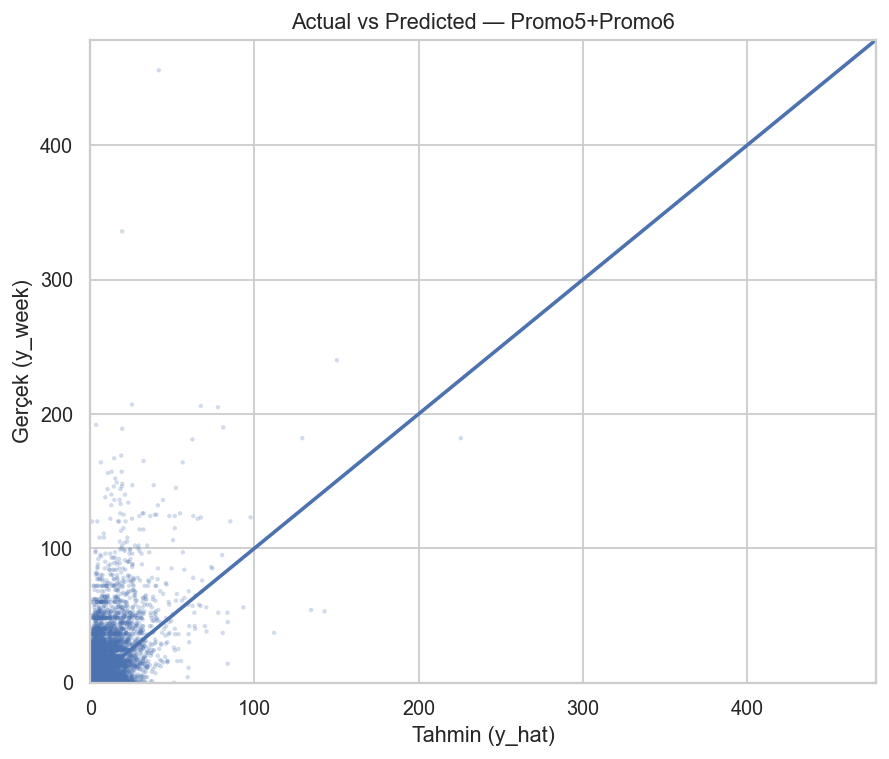

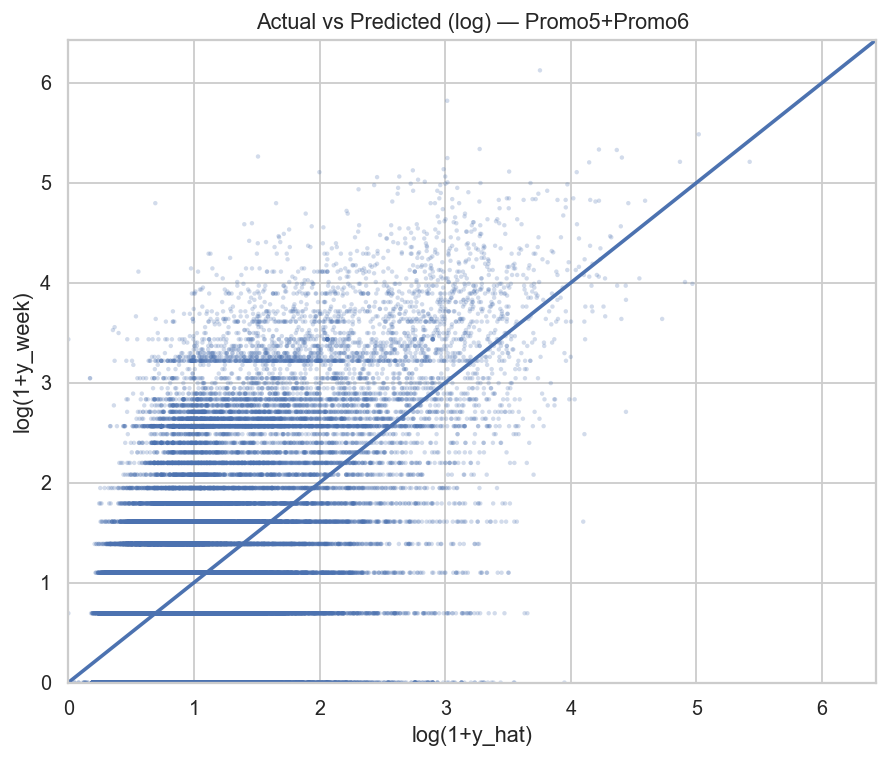

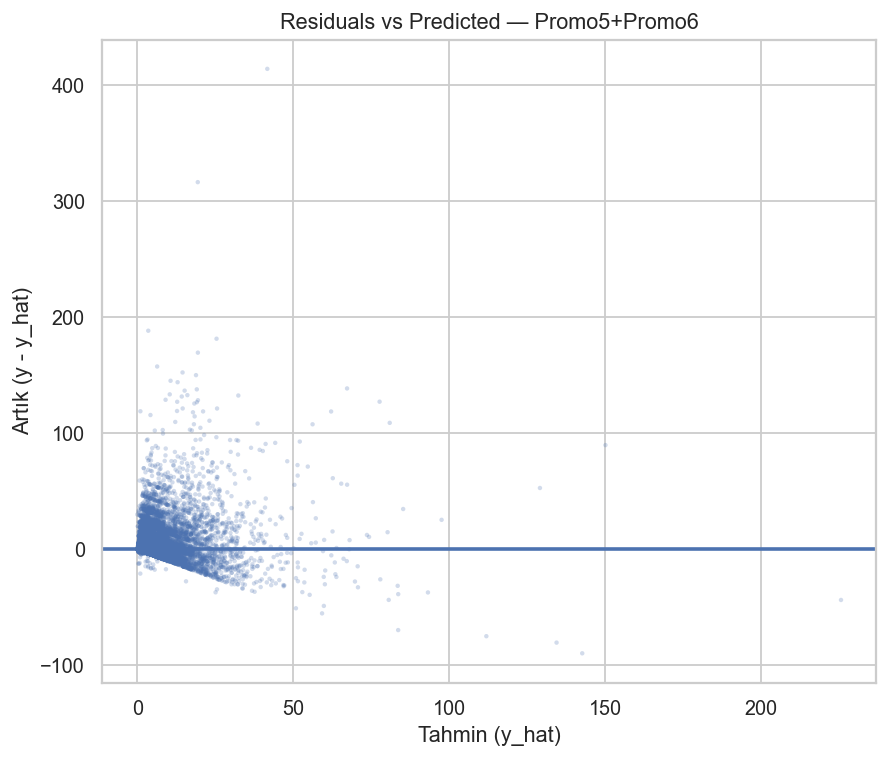

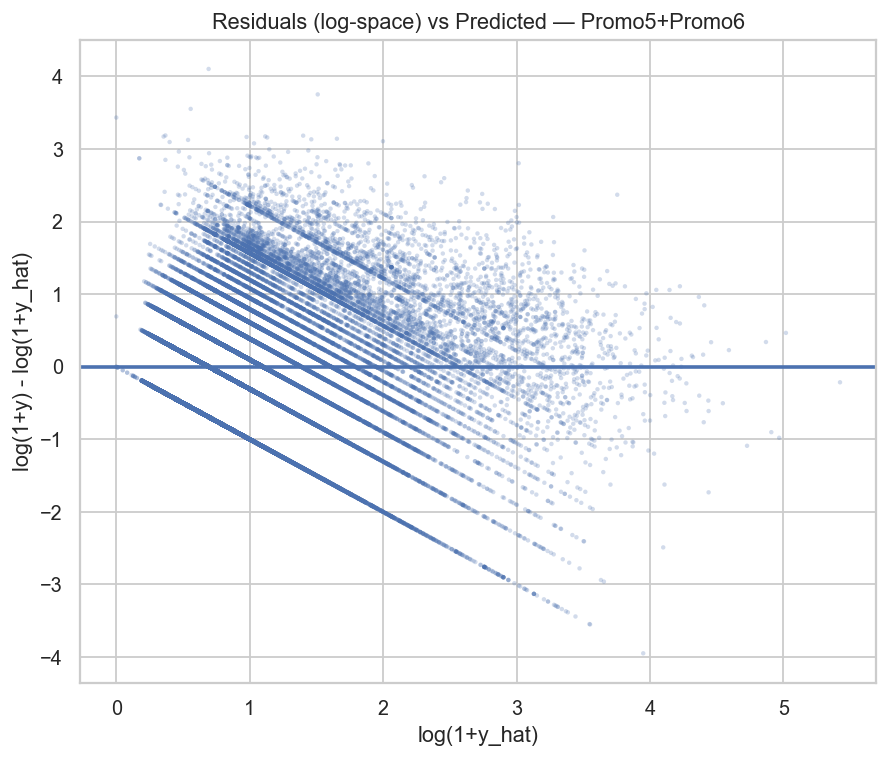

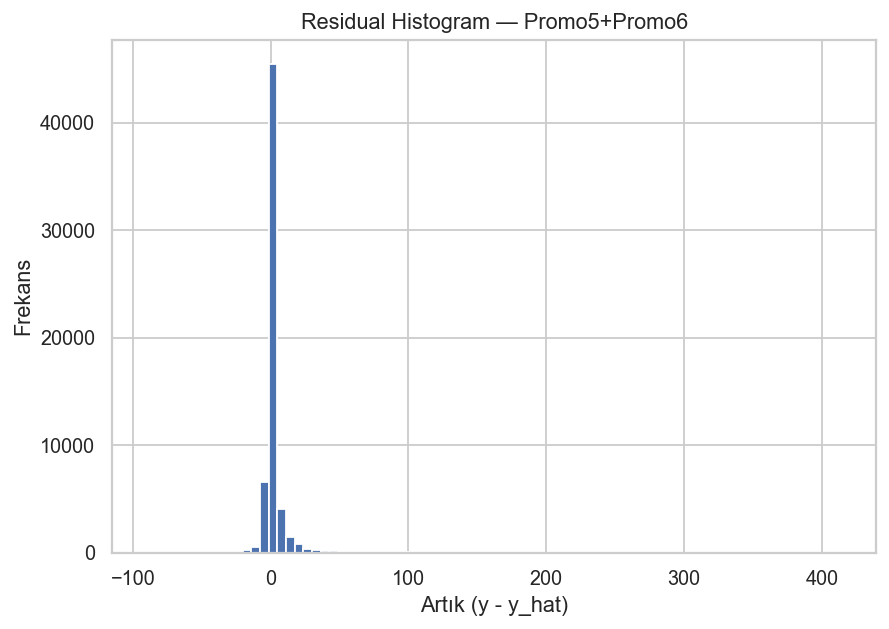

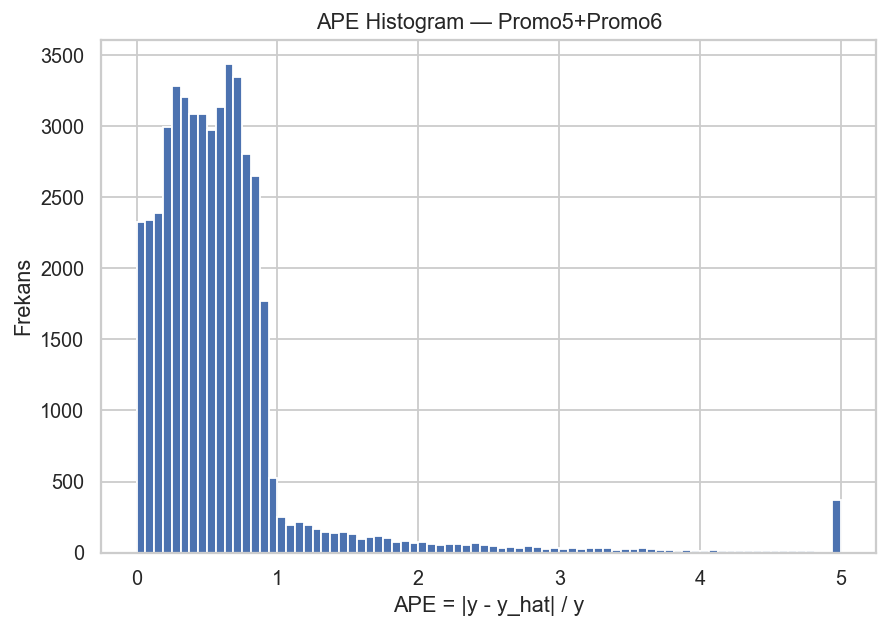

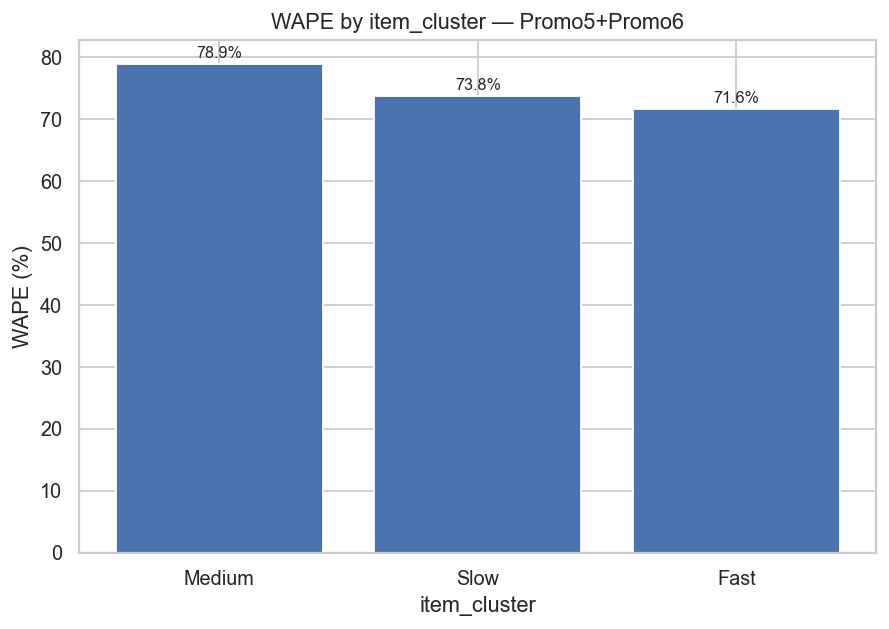

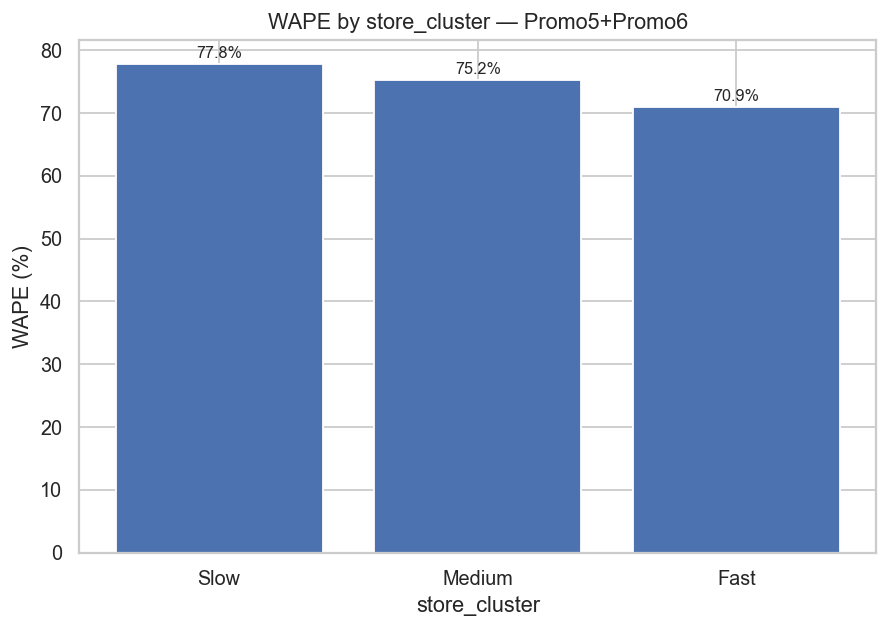

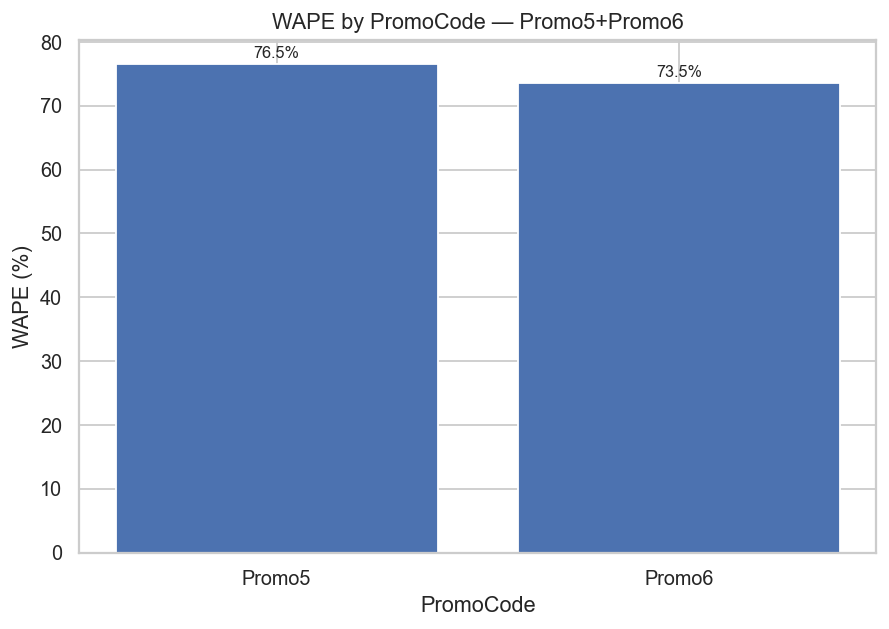

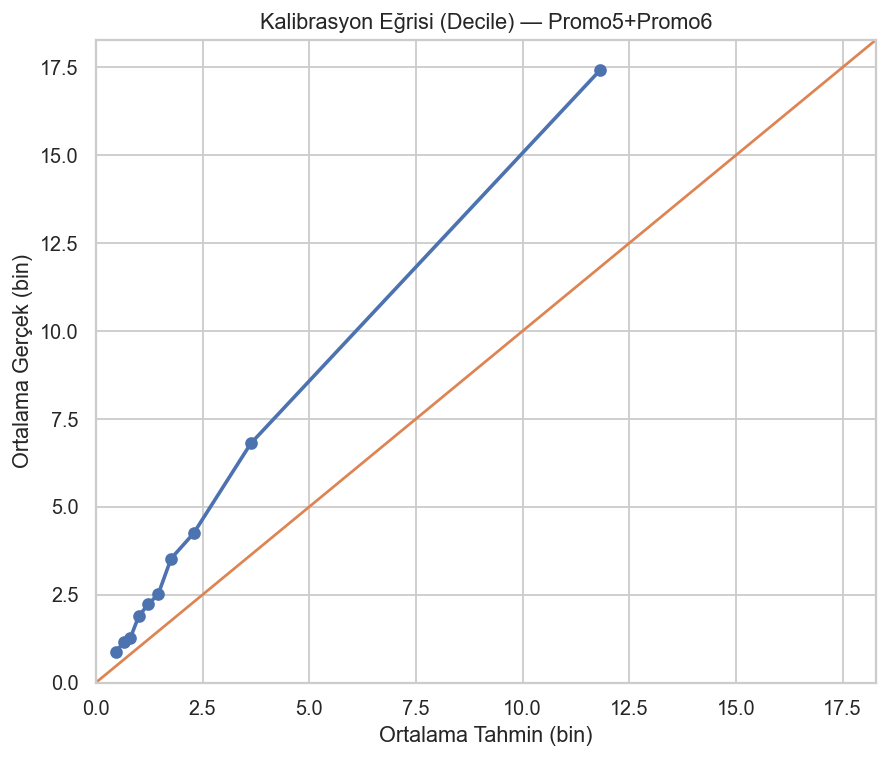

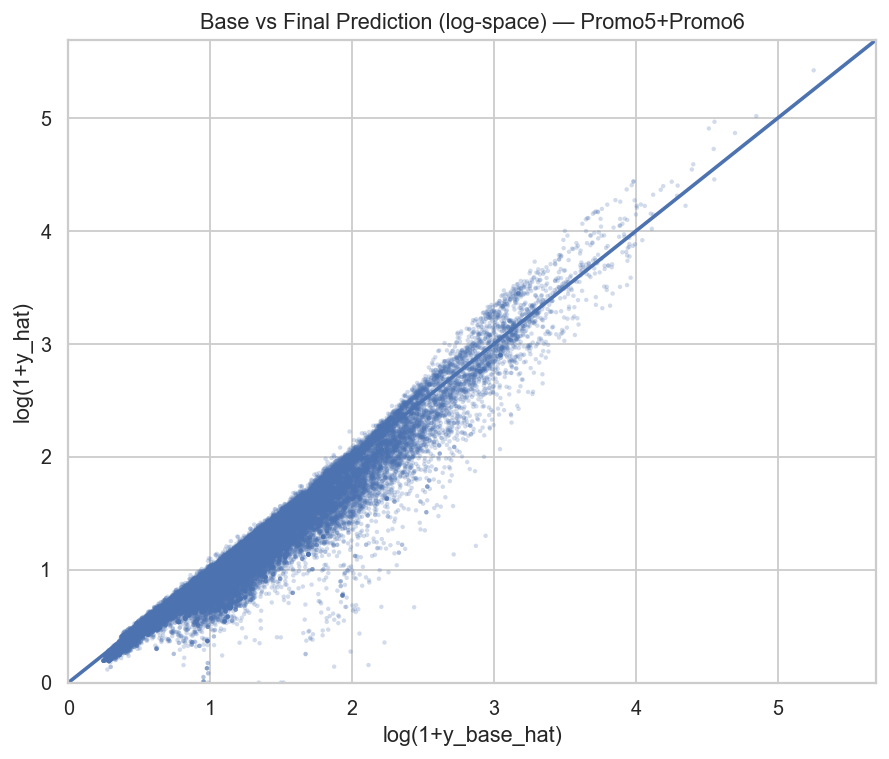

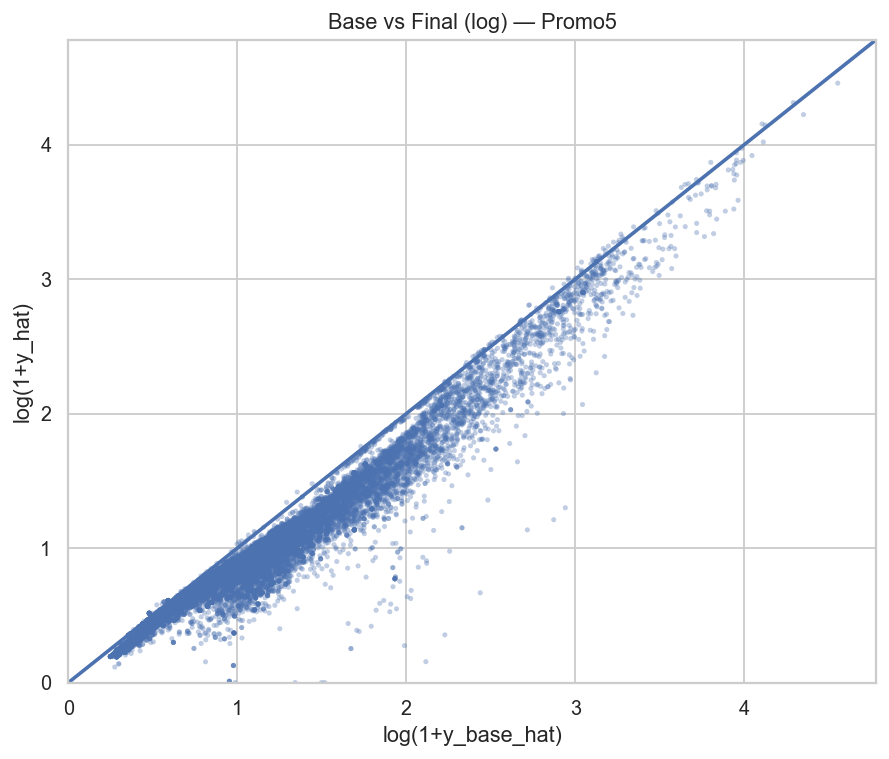

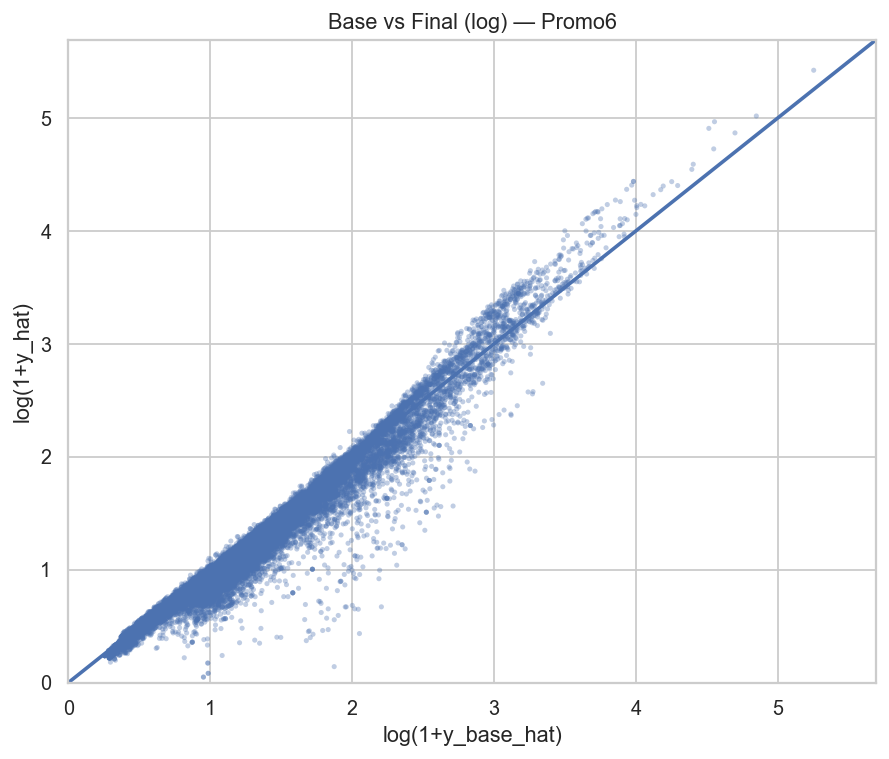


[Seri seçimi] Worst 5 örnek:
 StoreCode  ProductCode  WeekStart PromoCode  y_week     y_hat  y_base_hat item_cluster store_cluster
       218          171 2015-11-16    Promo6     456 41.701326   41.857329       Medium          Fast
       218          172 2015-11-16    Promo6     336 19.402316   20.116151       Medium          Fast
       143          184 2015-08-31    Promo5     192  3.525059    8.234473       Medium          Slow
       205          221 2015-08-31    Promo5     207 25.420972   26.139570         Fast          Fast
         7          218 2015-08-31    Promo5     189 19.434981   21.227830         Fast        Medium

[Seri seçimi] Best 5 örnek:
 StoreCode  ProductCode  WeekStart PromoCode  y_week    y_hat  y_base_hat item_cluster store_cluster
       124          139 2015-08-31    Promo5       0 0.000000    2.825739       Medium          Slow
       195          139 2015-08-31    Promo5       0 0.000000    3.558110       Medium        Medium
        38          142 20

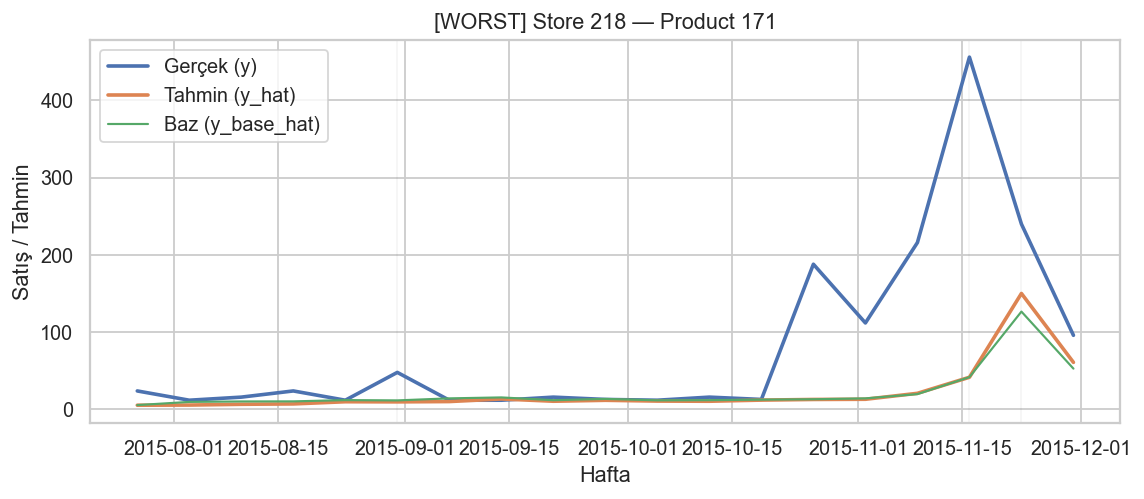

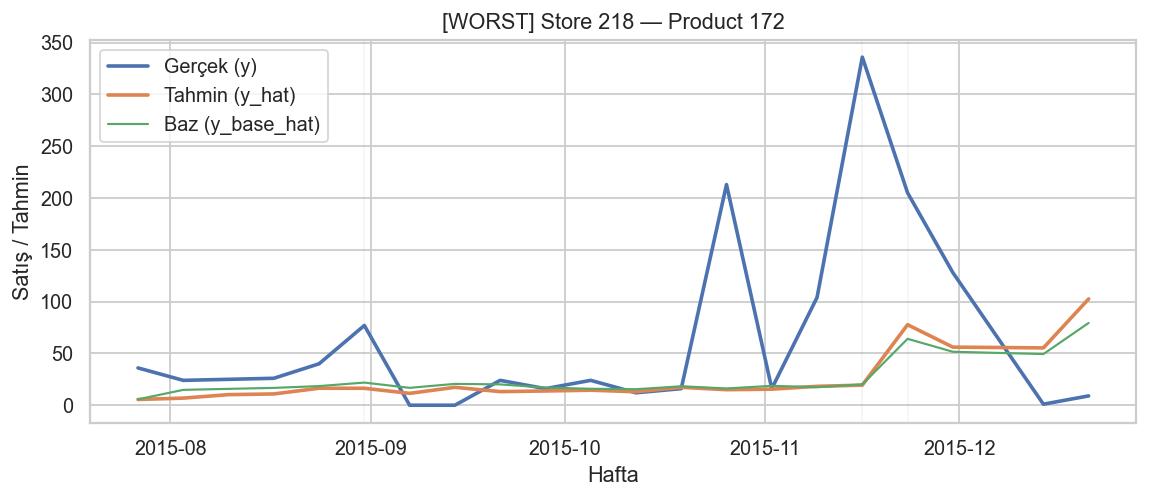

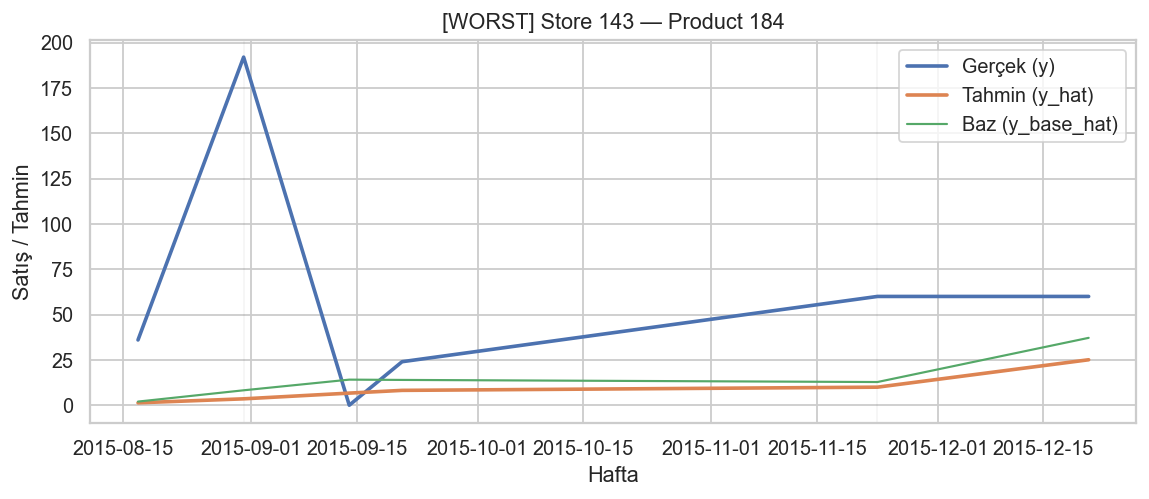

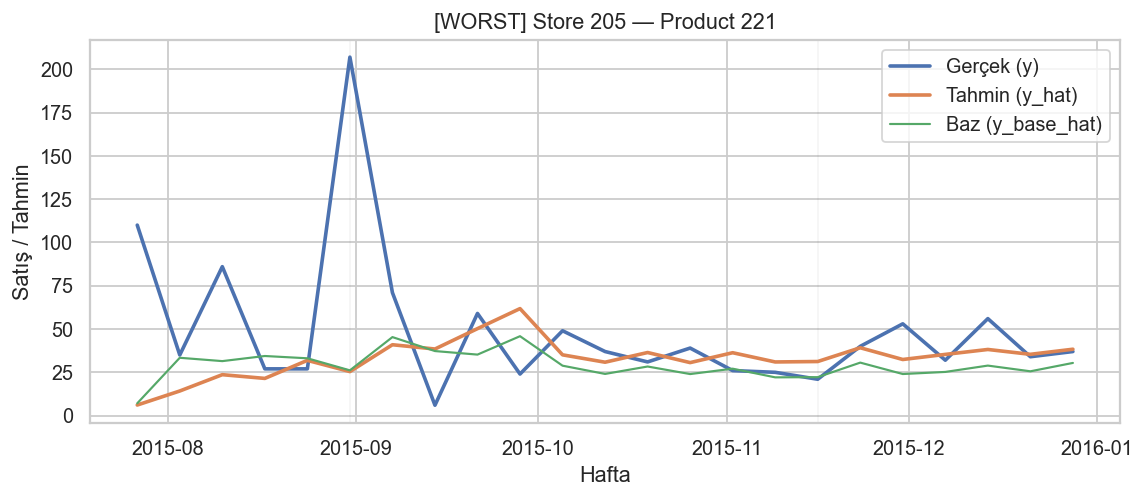

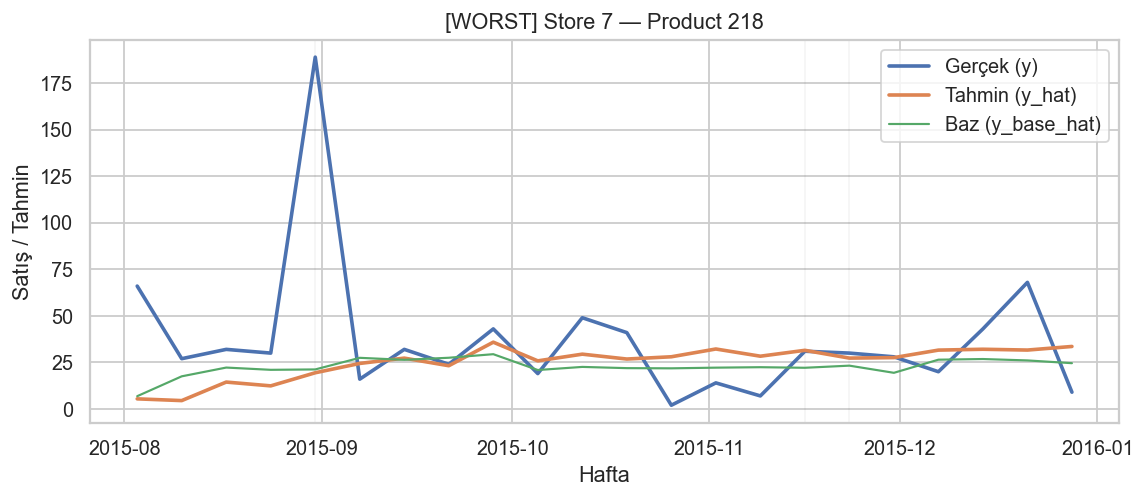

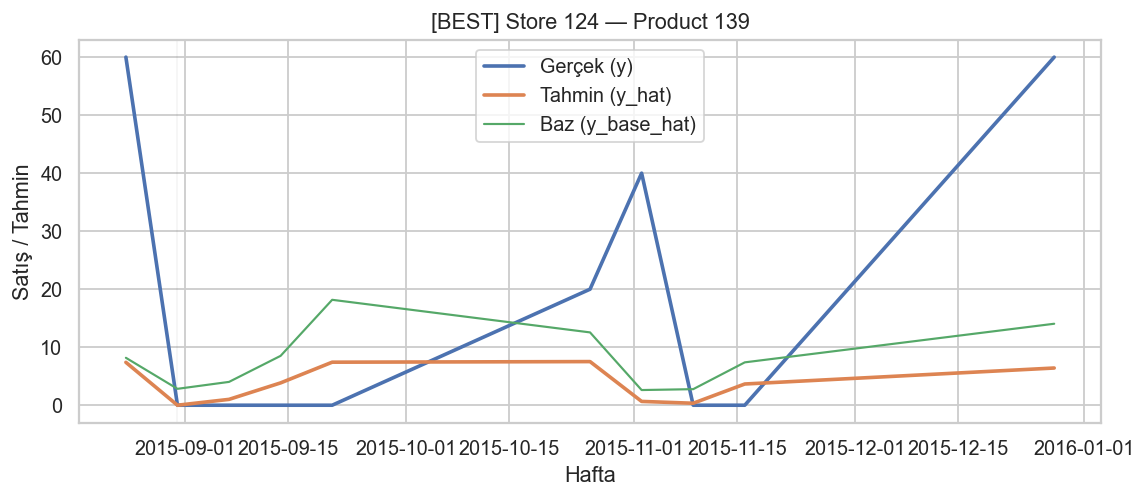

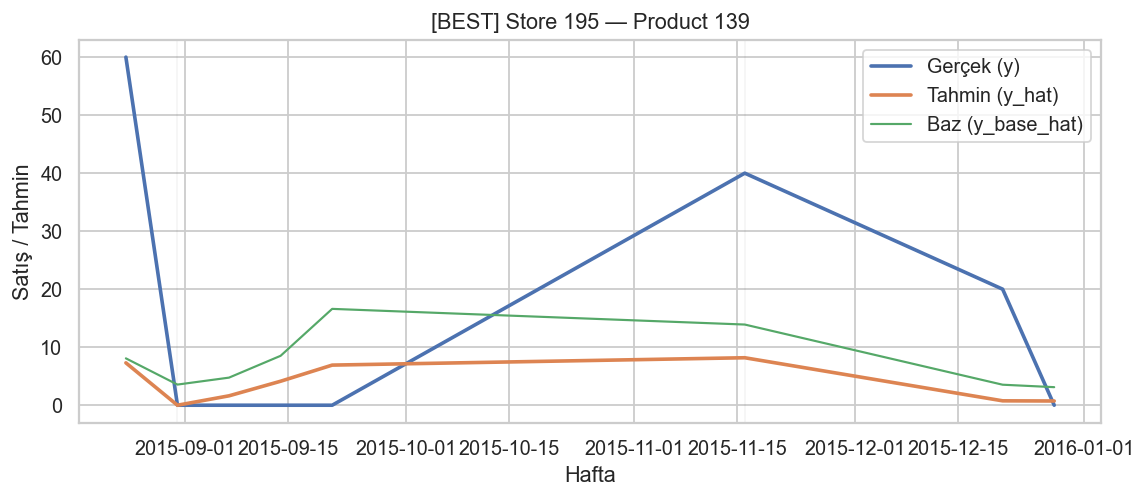

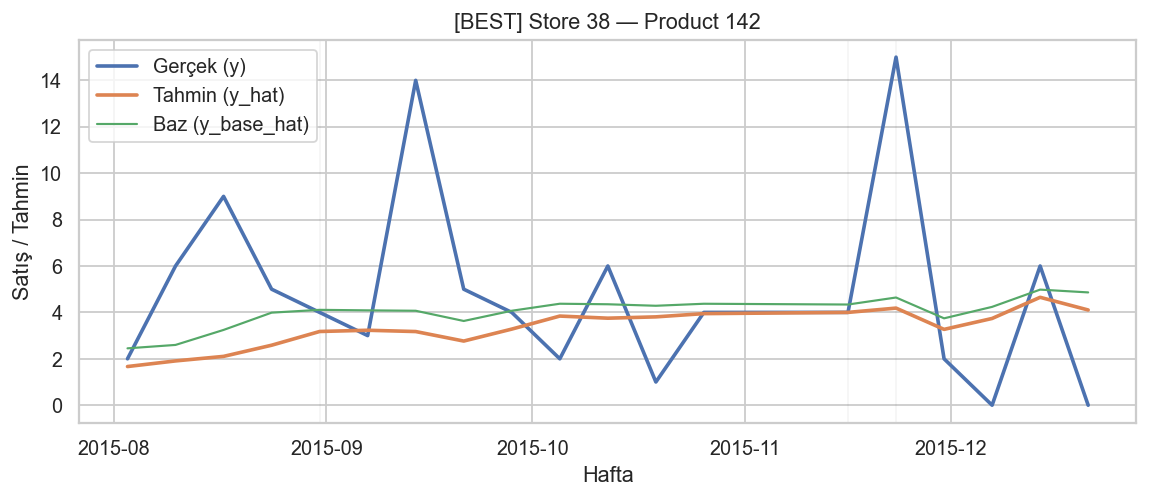

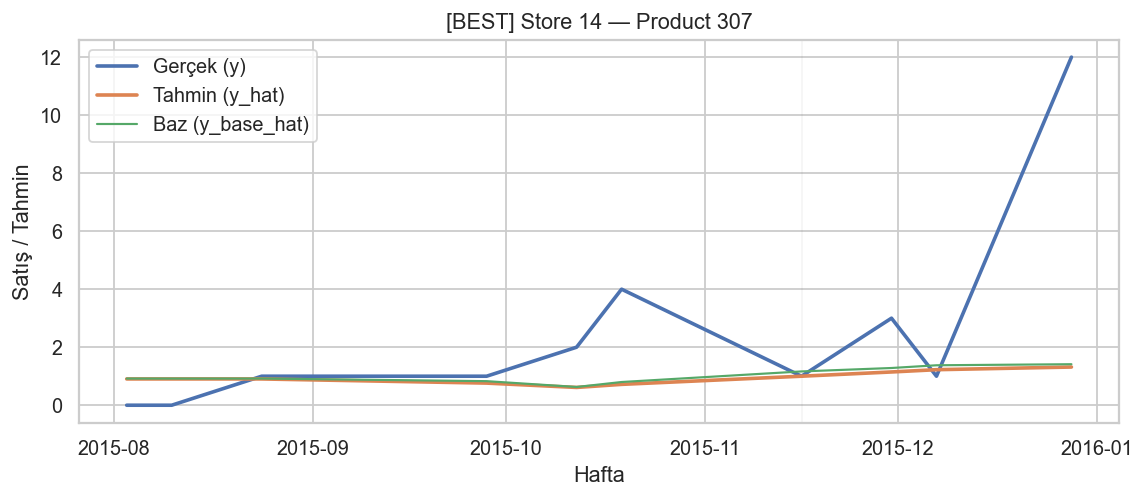

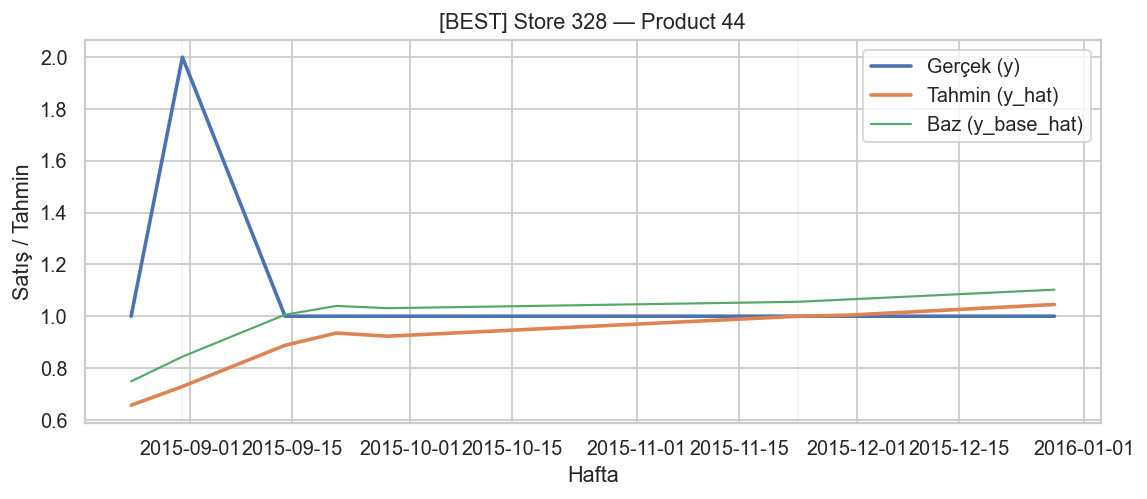


✅ Grafik üretimi tamam. 'figs/' klasörüne kaydedildi ve ekranda gösterildi.


In [78]:
# ============================
# GRAFİK PAKETİ — Promo5/6 Test Seti için
# ============================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- güvenli figür klasörü
os.makedirs("figs", exist_ok=True)

# --- test setinde gerekli kolonlar
req_cols = ["y_week","y_hat","y_base_hat","PromoFlag","PromoCode",
            "item_cluster","store_cluster","WeekStart","StoreCode","ProductCode"]
missing = [c for c in req_cols if c not in test.columns]
if missing:
    print("Eksik kolon(lar):", missing)

# --- metrikler & artıkları hazırla
plot = test.copy()
plot = plot.loc[(plot["PromoFlag"]==1) & (plot["PromoCode"].isin(["Promo5","Promo6"]))].copy()

plot["resid"]   = plot["y_week"] - plot["y_hat"]
plot["abs_err"] = plot["resid"].abs()
plot["ape"]     = np.where(plot["y_week"]>0, plot["abs_err"]/plot["y_week"], np.nan)  # % hata
plot["log_y"]   = np.log1p(plot["y_week"])
plot["log_yhat"]= np.log1p(plot["y_hat"])
plot["log_base"]= np.log1p(plot["y_base_hat"])

# ============================
# 1) Actual vs Predicted (lineer ve log)
# ============================
def plot_actual_vs_predicted(df, title_suffix="Promo5+Promo6"):
    fig, ax = plt.subplots(figsize=(7,6))
    ax.scatter(df["y_hat"], df["y_week"], s=6, alpha=0.25, edgecolor="none")
    lim = (0, max(df["y_hat"].max(), df["y_week"].max())*1.05)
    ax.plot(lim, lim, lw=2)  # 45 derece
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Tahmin (y_hat)")
    ax.set_ylabel("Gerçek (y_week)")
    ax.set_title(f"Actual vs Predicted — {title_suffix}")
    plt.tight_layout(); plt.savefig(f"figs/actual_vs_pred_{title_suffix}.png", dpi=160); plt.show()

    # log-ölçek
    fig, ax = plt.subplots(figsize=(7,6))
    ax.scatter(df["log_yhat"], df["log_y"], s=6, alpha=0.25, edgecolor="none")
    lim = (0, max(df["log_yhat"].max(), df["log_y"].max())*1.05)
    ax.plot(lim, lim, lw=2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("log(1+y_hat)")
    ax.set_ylabel("log(1+y_week)")
    ax.set_title(f"Actual vs Predicted (log) — {title_suffix}")
    plt.tight_layout(); plt.savefig(f"figs/actual_vs_pred_log_{title_suffix}.png", dpi=160); plt.show()

plot_actual_vs_predicted(plot)

# ============================
# 2) Residuals vs Predicted (heteroskedastisite/ölçek hatası kontrolü)
# ============================
def plot_resid_vs_pred(df, title_suffix="Promo5+Promo6"):
    fig, ax = plt.subplots(figsize=(7,6))
    ax.scatter(df["y_hat"], df["resid"], s=6, alpha=0.25, edgecolor="none")
    ax.axhline(0, lw=2)
    ax.set_xlabel("Tahmin (y_hat)")
    ax.set_ylabel("Artık (y - y_hat)")
    ax.set_title(f"Residuals vs Predicted — {title_suffix}")
    plt.tight_layout(); plt.savefig(f"figs/resid_vs_pred_{title_suffix}.png", dpi=160); plt.show()

    # log-ölçek artık
    fig, ax = plt.subplots(figsize=(7,6))
    ax.scatter(df["log_yhat"], df["log_y"] - df["log_yhat"], s=6, alpha=0.25, edgecolor="none")
    ax.axhline(0, lw=2)
    ax.set_xlabel("log(1+y_hat)")
    ax.set_ylabel("log(1+y) - log(1+y_hat)")
    ax.set_title(f"Residuals (log-space) vs Predicted — {title_suffix}")
    plt.tight_layout(); plt.savefig(f"figs/resid_log_vs_pred_{title_suffix}.png", dpi=160); plt.show()

plot_resid_vs_pred(plot)

# ============================
# 3) Residual histogram & APE dağılımı
# ============================
def plot_error_distributions(df, title_suffix="Promo5+Promo6"):
    fig, ax = plt.subplots(figsize=(7,5))
    ax.hist(df["resid"].values, bins=80)
    ax.set_title(f"Residual Histogram — {title_suffix}")
    ax.set_xlabel("Artık (y - y_hat)"); ax.set_ylabel("Frekans")
    plt.tight_layout(); plt.savefig(f"figs/hist_resid_{title_suffix}.png", dpi=160); plt.show()

    fig, ax = plt.subplots(figsize=(7,5))
    # APE’de sonsuz/nan temizle
    _ape = df["ape"].replace([np.inf, -np.inf], np.nan).dropna().clip(upper=5.0)  # aşırı outlier kes
    ax.hist(_ape.values, bins=80)
    ax.set_title(f"APE Histogram — {title_suffix}")
    ax.set_xlabel("APE = |y - y_hat| / y"); ax.set_ylabel("Frekans")
    plt.tight_layout(); plt.savefig(f"figs/hist_ape_{title_suffix}.png", dpi=160); plt.show()

plot_error_distributions(plot)

# ============================
# 4) WAPE kırılımları: item_cluster, store_cluster, PromoCode
# ============================
def wape_np(y, yhat):
    denom = np.abs(y).sum()
    return np.nan if denom==0 else np.abs(y - yhat).sum() / denom

def bar_wape_by(df, by, title):
    agg = (df
           .groupby(by)
           .apply(lambda g: wape_np(g["y_week"].values, g["y_hat"].values))
           .sort_values(ascending=False)
           .rename("WAPE")
           .reset_index())
    fig, ax = plt.subplots(figsize=(7,5))
    ax.bar(agg[by].astype(str), agg["WAPE"]*100.0)
    ax.set_ylabel("WAPE (%)"); ax.set_xlabel(by)
    ax.set_title(title)
    for i, v in enumerate(agg["WAPE"]*100.0):
        ax.text(i, v+0.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.savefig(f"figs/wape_by_{by}.png", dpi=160); plt.show()
    return agg

wape_item  = bar_wape_by(plot, "item_cluster",  "WAPE by item_cluster — Promo5+Promo6")
wape_store = bar_wape_by(plot, "store_cluster", "WAPE by store_cluster — Promo5+Promo6")
if "PromoCode" in plot.columns:
    wape_promo = bar_wape_by(plot, "PromoCode", "WAPE by PromoCode — Promo5+Promo6")

# ============================
# 5) Kalibrasyon eğrisi: decile’lere göre ort. tahmin vs ort. gerçek
# ============================
def calibration_curve(df, nbins=10, title_suffix="Promo5+Promo6"):
    df = df.copy()
    df["bin"] = pd.qcut(df["y_hat"].rank(method="first"), q=nbins, labels=False)
    cal = (df.groupby("bin")[["y_hat","y_week"]].mean().reset_index())
    fig, ax = plt.subplots(figsize=(7,6))
    ax.plot(cal["y_hat"], cal["y_week"], marker="o", lw=2)
    lim = (0, max(cal["y_hat"].max(), cal["y_week"].max())*1.05)
    ax.plot(lim, lim, lw=1.5)  # ideal çizgi
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Ortalama Tahmin (bin)")
    ax.set_ylabel("Ortalama Gerçek (bin)")
    ax.set_title(f"Kalibrasyon Eğrisi (Decile) — {title_suffix}")
    plt.tight_layout(); plt.savefig(f"figs/calibration_{title_suffix}.png", dpi=160); plt.show()
    return cal

cal_table = calibration_curve(plot)

# ============================
# 6) Uplift ayrıştırma: base vs final (log uzayında)
# ============================
def plot_base_vs_final(df, title_suffix="Promo5+Promo6"):
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(df["log_base"], df["log_yhat"], s=6, alpha=0.25, edgecolor="none")
    lim = (0, max(df["log_base"].max(), df["log_yhat"].max())*1.05)
    ax.plot(lim, lim, lw=2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("log(1+y_base_hat)")
    ax.set_ylabel("log(1+y_hat)")
    ax.set_title(f"Base vs Final Prediction (log-space) — {title_suffix}")
    plt.tight_layout(); plt.savefig(f"figs/base_vs_final_log_{title_suffix}.png", dpi=160); plt.show()

    # PromoCode renklendirme (ayrı figürler — overlap azaltmak için)
    for p in sorted(df["PromoCode"].dropna().unique()):
        sub = df[df["PromoCode"]==p]
        if sub.empty: 
            continue
        fig, ax = plt.subplots(figsize=(7,6))
        ax.scatter(sub["log_base"], sub["log_yhat"], s=8, alpha=0.35, edgecolor="none")
        lim = (0, max(sub["log_base"].max(), sub["log_yhat"].max())*1.05)
        ax.plot(lim, lim, lw=2)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel("log(1+y_base_hat)")
        ax.set_ylabel("log(1+y_hat)")
        ax.set_title(f"Base vs Final (log) — {p}")
        plt.tight_layout(); plt.savefig(f"figs/base_vs_final_log_{p}.png", dpi=160); plt.show()

plot_base_vs_final(plot)

# ============================
# 7) Örnek zaman serisi grafikleri (worst/best örnekler)
# ============================
def series_plot(df, key, title_prefix=""):
    sc, pc = key
    sub = test.copy()  # tüm haftaları göster
    sub = sub[(sub["StoreCode"]==sc) & (sub["ProductCode"]==pc)].sort_values("WeekStart")
    if sub.empty: 
        print("Boş seri:", key); 
        return
    fig, ax = plt.subplots(figsize=(9,4))
    ax.plot(sub["WeekStart"], sub["y_week"], lw=2, label="Gerçek (y)")
    ax.plot(sub["WeekStart"], sub["y_hat"],  lw=2, label="Tahmin (y_hat)")
    ax.plot(sub["WeekStart"], sub["y_base_hat"], lw=1.2, label="Baz (y_base_hat)")
    # Promo dönemlerini zemin renkle vurgula
    promos = sub[sub["PromoFlag"]==1]
    for dt in promos["WeekStart"]:
        ax.axvspan(dt, dt, color="k", alpha=0.04)  # tek nokta highlight
    ax.set_title(f"{title_prefix} Store {sc} — Product {pc}")
    ax.set_xlabel("Hafta"); ax.set_ylabel("Satış / Tahmin")
    ax.legend()
    plt.tight_layout(); plt.savefig(f"figs/series_{sc}_{pc}.png", dpi=160); plt.show()

# Worst/Best 5 örneği al ve çiz
tmp = plot.copy()
tmp["abs_err"] = (tmp["y_week"] - tmp["y_hat"]).abs()
cols = ["StoreCode","ProductCode","WeekStart","PromoCode","y_week","y_hat","y_base_hat","item_cluster","store_cluster"]
print("\n[Seri seçimi] Worst 5 örnek:")
print(tmp.nlargest(5,"abs_err")[cols].to_string(index=False))
print("\n[Seri seçimi] Best 5 örnek:")
print(tmp.nsmallest(5,"abs_err")[cols].to_string(index=False))

worst_keys = tmp.nlargest(5,"abs_err")[["StoreCode","ProductCode"]].drop_duplicates().itertuples(index=False, name=None)
best_keys  = tmp.nsmallest(5,"abs_err")[["StoreCode","ProductCode"]].drop_duplicates().itertuples(index=False, name=None)

for k in worst_keys:
    series_plot(plot, k, title_prefix="[WORST]")

for k in best_keys:
    series_plot(plot, k, title_prefix="[BEST]")

# ============================
# 8) (Opsiyonel) Permutation Importance görselleştirme
#     RUN_PERM=True ile hesapladıysan imp_df tabloyu çiz
# ============================
try:
    # Eğer daha önce RUN_PERM bloğunda imp_df ürettiysen, buradan bar plot
    if "imp_df" in globals():
        top = imp_df.sort_values("importance", ascending=False).head(20)
        fig, ax = plt.subplots(figsize=(8,6))
        ax.barh(top["feature"], top["importance"])
        ax.invert_yaxis()
        ax.set_title("Permutation Importance (Uplift) — Top 20")
        ax.set_xlabel("Önem (ortalama düşüş)")
        plt.tight_layout(); plt.savefig("figs/perm_importance_top20.png", dpi=160); plt.show()
except Exception as e:
    print("(Info) Permutation importance grafiği atlandı:", e)

print("\n✅ Grafik üretimi tamam. 'figs/' klasörüne kaydedildi ve ekranda gösterildi.")
